In [1]:
import pandas as pd
import numpy as np
from tslearn.clustering import TimeSeriesKMeans
import matplotlib.pyplot as plt
from utils import *
import math

In [2]:
# df_1_hME1_scaled = pd.read_excel("Experiment/1_hTERT_HME1/Data/Processed/Full_dataset_1_hTERT_HME1_functional_names_diff_scaled_phPlus_localized.xlsx")
# df_1_hME1_scaled = df_1_hME1_scaled.fillna(0)

df_2_hME1_scaled = pd.read_excel("Experiment/2_hTERT_HME1/Data/Processed/Full_dataset_2_hTERT_HME1_functional_names_diff_scaled_phPlus.xlsx")
df_2_hME1_scaled = df_2_hME1_scaled.fillna(0)

# df_1_HEK_scaled = pd.read_excel("Experiment/1_HEK293T/Data/Processed/Full_dataset_HEK293T_functional_names_diff_scaled_phPlus.xlsx")
# df_1_HEK_scaled = df_1_HEK_scaled.fillna(0)

In [3]:
df_2_hME1_scaled

,protein_Id,description,protein_name,Peptide,MaxPepProbability,site_start,site_end,n_sites,localized_sites,phospho_sites,...,FC_scaled_EGFnINS_starve,FC_scaled_EGFnINS_2,FC_scaled_EGFnINS_5,FC_scaled_EGFnINS_10,FC_scaled_EGFnINS_15,FC_scaled_EGFnINS_90,functional_score,ms_lit,ERK_motif,ERK_ext_motif
0,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SGSGNFGGGR,0.9956,197,199,1,0,0,...,0,-0.035173,0.090278,0.206244,0.684762,0.659816,0.0,0.0,0.0,0.0
1,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SGsGNFGGGR,1.0000,197,199,1,1,S199,...,0,-0.049035,0.167233,0.418818,0.585366,0.779797,0.0,0.0,0.0,0.0
2,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SKSEsPKEPEQLR,1.0000,2,6,1,1,S6,...,0,-0.673611,-0.487599,-0.781955,-0.057160,-0.119301,0.0,0.0,0.0,0.0
3,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,sKsESPK,0.9894,2,6,2,2,S2;S4,...,0,-1.000000,-0.178269,-0.869578,-0.794457,-0.810823,0.0,0.0,0.0,0.0
4,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,NQGGYGGSSSSSSYGSGR;NQGGYGGSSSSSSYGSGRRF,1.0000,305,316,1,0,0,...,0,-0.248076,0.255346,0.676671,0.976998,0.341977,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50009,rev_Q5VWT5,0,0,GALMNRRGtHVNtMQIK,0.9898,303,307,2,2,T303;T307,...,0,-0.107027,0.072819,0.713544,0.419371,0.830938,0.0,0.0,0.0,0.0
50010,rev_Q8N6M0,0,0,LQDEIAKYMCHGDsPIQK,0.9970,135,141,1,1,S141,...,0,0.348857,0.520648,0.721462,0.458464,0.500749,0.0,0.0,0.0,0.0
50011,rev_Q96M83,0,0,ERGPtIKK,0.9835,505,505,1,1,T505,...,0,0.125190,0.618619,1.000000,0.823704,0.792848,0.0,0.0,0.0,0.0
50012,rev_Q9ULL1,0,0,SSASSSTSGFSVPR,0.9787,1366,1376,2,0,0,...,0,-0.086244,1.000000,0.257387,0.066917,-0.174938,0.0,0.0,0.0,0.0


In [23]:
extremes = filter_dynamics_extremes(df_2_hME1_scaled, data_type = "log2_mean", threshold=16, exclude_full=False)
within = filter_dynamics_within(df_2_hME1_scaled, data_type = "log2_mean", threshold=16, exclude_full=False)
print(len(df_2_hME1_scaled),len(extremes), len(within))

50014 38826 11188


In [16]:
def dynamics_values(
        df,
        data_type="log2_FC",
        exclude_full = True,):
    if exclude_full == True:
        column_selection = [element for element in df.columns if
                            element.startswith(f"{data_type}") and "full" not in element]
    else:
        column_selection = [c for c in df.columns if data_type in c and "statistics" not in c]

    return df[column_selection].copy()

In [25]:
pp = dynamics_values(df_2_hME1_scaled, data_type="log2_FC", exclude_full=False)
pp

,log2_FC_EGF_full,log2_FC_EGF_starve,log2_FC_EGF_2,log2_FC_EGF_5,log2_FC_EGF_10,log2_FC_EGF_15,log2_FC_EGF_90,log2_FC_INS_full,log2_FC_INS_starve,log2_FC_INS_2,...,log2_FC_INS_10,log2_FC_INS_15,log2_FC_INS_90,log2_FC_EGFnINS_full,log2_FC_EGFnINS_starve,log2_FC_EGFnINS_2,log2_FC_EGFnINS_5,log2_FC_EGFnINS_10,log2_FC_EGFnINS_15,log2_FC_EGFnINS_90
0,0.333377,0,-0.085447,-0.109984,0.096114,-0.054877,0.099930,0.333377,0,-0.141487,...,0.080687,0.227212,0.121297,0.333377,0,-0.011726,0.030097,0.068757,0.228284,0.219967
1,1.865246,0,-0.015958,0.104470,0.538362,0.306230,0.331917,1.865246,0,-0.322750,...,0.397951,1.142118,1.214255,1.865246,0,-0.091463,0.311930,0.781198,1.091852,1.454514
2,-0.041942,0,-0.054637,-0.057321,-0.191272,-0.022961,0.054337,-0.041942,0,-0.176562,...,-0.102275,-0.088688,-0.196548,-0.041942,0,-0.151226,-0.109466,-0.175549,-0.012832,-0.026783
3,-0.280358,0,-0.298706,-0.228213,-0.284106,-0.278502,-0.205442,-0.280358,0,-0.078628,...,-0.031996,-0.217610,-0.061732,-0.280358,0,-0.303903,-0.054177,-0.264268,-0.241438,-0.246412
4,-0.062460,0,-0.018512,-0.038545,0.010967,0.064828,0.003713,-0.062460,0,-0.141901,...,-0.057154,0.075104,0.103210,-0.062460,0,-0.035202,0.036234,0.096021,0.138637,0.048527
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50009,0.063861,0,0.006749,0.033117,0.028042,0.038591,0.018571,0.063861,0,-0.006584,...,0.016246,0.035558,0.022911,0.063861,0,-0.006835,0.004650,0.045568,0.026781,0.053064
50010,0.003498,0,0.066298,0.071347,0.016413,0.020867,0.019018,0.003498,0,0.060013,...,0.037839,0.026239,0.045139,0.003498,0,0.024890,0.037147,0.051474,0.032710,0.035727
50011,0.006897,0,0.045342,0.098785,0.043829,-0.055680,-0.023152,0.006897,0,0.113937,...,0.099389,0.071374,0.113039,0.006897,0,0.018156,0.089715,0.145024,0.119457,0.114982
50012,0.010188,0,0.009463,0.018484,-0.027445,-0.008558,-0.016031,0.010188,0,0.004352,...,0.030823,0.034150,-0.013520,0.010188,0,-0.010114,0.117277,0.030185,0.007848,-0.020516


# Filter data

In [41]:
dataframe = df_2_hME1_scaled.copy()
######### Phospho site localization
# > 0 means localized site (at least one)
# = 0 means no localized
subdata = dataframe.loc[dataframe["localized_sites"] > 0]

######### Phospho site replicates
# > 1 means at least 2 reps
# > 2 means at least 3 reps
subdata = subdata.loc[subdata["n_rep"] > 1]

######### ERK motif
# 0 means no ERK motif
# 1 means yes ERK motif
subdata_erk_motif = subdata.loc[subdata["ERK_motif"] == 1]

######### functional score
subdata_f_score = subdata.loc[subdata["functional_score"] > 0.5]


combined = subdata_erk_motif.loc[subdata_erk_motif["functional_score"] > 0.5]
# ######### ms lit
# subdata_ms_lit = subdata.loc[subdata["ms_lit"] > 0.5]

In [5]:
print(f"Length of original dataframe = {len(dataframe)}")
# Filter based in profile parameter
subdata = subdata.copy()

print(f"len(subdata) [(localized_sites > 0) & (n_rep > 1)] = {len(subdata)}")
##################### FC threshold
data_type = "log2_FC" #
column_names = subdata.columns.tolist()
column_selection = [element for element in column_names if element.startswith(f"{data_type}") and "full" not in element]

mask = subdata[column_selection].abs().max(axis=1) > 0.5
subdata_fc = subdata.loc[mask].copy()
print(f"len(subdata_fc) [FC >0.5] = {len(subdata_fc)}")

print(f"Clustering based on {column_selection}")
# data_type = "log2_FC" #
# column_names = subdata.columns.tolist()
# column_selection = [element for element in column_names if element.startswith(f"{data_type}") and "full" not in element]
#
# mask = subdata_fc[column_selection].abs().max(axis=1) > 0.3
# subdata_fc_2 = subdata_fc.loc[mask].copy()
# print(f"len(subdata_fc_2) [0.3 < FC < 0.5)]= {len(subdata_fc_2)}")
# subdata_fc
#################### PVALUE
# data_type = "FC_pvalue" #data type over which I want to do the filtering and the clustering
#
# column_names = subdata.columns.tolist()
# column_selection = [element for element in column_names if f"{data_type}" in element and "full" not in element and "starve" not in element]
# neglog10 = -np.log10(subdata[column_selection])
# mask = (neglog10 > 2).any(axis=1)
# # mask = subdata[column_selection].max(axis=1) > 0.05 #dont understand why i have to it this way
# subdata_pv = subdata.loc[mask].copy()
# print(len(subdata_pv))

Length of original dataframe = 50014
len(subdata) [(localized_sites > 0) & (n_rep > 1)] = 24268
len(subdata_fc) [FC >0.5] = 5614
Clustering based on ['log2_FC_EGF_starve', 'log2_FC_EGF_2', 'log2_FC_EGF_5', 'log2_FC_EGF_10', 'log2_FC_EGF_15', 'log2_FC_EGF_90', 'log2_FC_INS_starve', 'log2_FC_INS_2', 'log2_FC_INS_5', 'log2_FC_INS_10', 'log2_FC_INS_15', 'log2_FC_INS_90', 'log2_FC_EGFnINS_starve', 'log2_FC_EGFnINS_2', 'log2_FC_EGFnINS_5', 'log2_FC_EGFnINS_10', 'log2_FC_EGFnINS_15', 'log2_FC_EGFnINS_90']


In [10]:
cluster_column_name = "testing" #[ERKmotif0]_  [Fscore>05]
data_to_cluster = subdata_fc.copy()

tslearn_clustering_KMeans(df_to_cluster = data_to_cluster,
                          data_type = "log2_FC",
                          cluster_column_name = cluster_column_name, #"DTW_log2_FC_locSize>0_nrep>1_5_KMeans_81clusters",
                          number_of_clusters = 25,
                          max_iterations = 500,
                          metric='dtw', # dtw, euclidean, softdtw
                          verbose = False )
# #3400 sites -> 4 mins (1000 max iterations, 81 clusters

df_1_HEK_scaled = pd.merge(df_1_HEK_scaled, data_to_cluster[["site", f"{cluster_column_name}"]], on="site", how="left")

df_1_HEK_scaled = df_1_HEK_scaled.fillna(999)

df_1_HEK_scaled[f"{cluster_column_name}"] = df_1_HEK_scaled[f"{cluster_column_name}"].astype(int)
#
df_2_hME1_scaled

# scaled_clustered_data = tslearn_clustering_KMeans(df_to_cluster = subdata_fc,
#                           data_type = "FC_scaled",
#                           cluster_column_name,
#                           number_of_clusters = 81,
#                           max_iterations = 1000,
#                           metric='euclidean', # dtw, euclidean, softdtw
#                           verbose = False)


KeyError: '       protein_Id                                        description  \\\n1      A0A2R8Y4L2  Heterogeneous nuclear ribonucleoprotein A1-lik...   \n15         A0AVK6  Transcription factor E2F8 OS=Homo sapiens OX=9...   \n21         A0FGR8  Extended synaptotagmin-2 OS=Homo sapiens OX=96...   \n29         A0FGR8  Extended synaptotagmin-2 OS=Homo sapiens OX=96...   \n38         A0FGR8  Extended synaptotagmin-2 OS=Homo sapiens OX=96...   \n...           ...                                                ...   \n49707      Q9UK53  Inhibitor of growth protein 1 OS=Homo sapiens ...   \n49740      Q9Y2L8  Zinc finger protein with KRAB and SCAN domains...   \n49746      Q9Y3Y2  Chromatin target of PRMT1 protein OS=Homo sapi...   \n49750      Q9Y4F4  TOG array regulator of axonemal microtubules p...   \n49753      Q9Y576  Ankyrin repeat and SOCS box protein 1 OS=Homo ...   \n\n      protein_name               Peptide  MaxPepProbability  site_start  \\\n1        HNRNPA1L3            SGs

In [34]:
# df_2_hME1_scaled.to_excel("Experiment/2_hTERT_HME1/Data/Processed/Full_dataset_2_hTERT_HME1_functional_names_diff_scaled_phPlus_clustered.xlsx", index=False)


,protein_Id,description,protein_name,Peptide,MaxPepProbability,site_start,site_end,n_sites,localized_sites,phospho_sites,...,KMeans_81clusters_DTW_on_log2_FC_[locSite>0]_[nrep>1]_[FC>1],KMeans_81clusters_DTW_on_log2_FC_[locSite>0]_[nrep>1]_[03>FC>05],KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>05]_[ERKmotif0],KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>05]_[Fscore>05],KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>05]_[ERKmotif0]_[Fscore>05],KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>05]_[ERKmotif1],KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>05]_[ERKmotif1]_[Fscore>05],KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>05],KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>1],KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[0.3<FC<05]
0,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SGSGNFGGGR,0.9956,197,199,1,0,0,...,999,999,999,999,999,999,999,999,999,999
1,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SGsGNFGGGR,1.0000,197,199,1,1,S199,...,43,999,21,999,999,999,999,10,35,999
2,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SKSEsPKEPEQLR,1.0000,2,6,1,1,S6,...,999,999,999,999,999,999,999,999,999,999
3,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,sKsESPK,0.9894,2,6,2,2,S2;S4,...,999,999,999,999,999,999,999,999,999,999
4,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,NQGGYGGSSSSSSYGSGR;NQGGYGGSSSSSSYGSGRRF,1.0000,305,316,1,0,0,...,999,999,999,999,999,999,999,999,999,999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50009,rev_Q5VWT5,0,0,GALMNRRGtHVNtMQIK,0.9898,303,307,2,2,T303;T307,...,999,999,999,999,999,999,999,999,999,999
50010,rev_Q8N6M0,0,0,LQDEIAKYMCHGDsPIQK,0.9970,135,141,1,1,S141,...,999,999,999,999,999,999,999,999,999,999
50011,rev_Q96M83,0,0,ERGPtIKK,0.9835,505,505,1,1,T505,...,999,999,999,999,999,999,999,999,999,999
50012,rev_Q9ULL1,0,0,SSASSSTSGFSVPR,0.9787,1366,1376,2,0,0,...,999,999,999,999,999,999,999,999,999,999


-------------------------------------------
# Plotting
------------------------------------------

In [26]:
df_cluster = pd.read_excel("Experiment/2_hTERT_HME1/Data/Processed/Full_dataset_2_hTERT_HME1_functional_names_diff_scaled_phPlus_clustered.xlsx")

In [4]:
# df_cluster.loc[df_cluster["protein_Id"] == "Q9Y3P9"]

In [27]:
columns = [element for element in df_cluster.columns.to_list() if "KMeans" in element]
for column in columns:
    print(column)

KMeans_81clusters_DTW_on_log2_FC_[locSite>0]_[nrep>1]_[FC>05]_[ERKmotif0]
KMeans_81clusters_DTW_on_log2_FC_[locSite>0]_[nrep>1]_[FC>05]_[Fscore>05]
KMeans_81clusters_DTW_on_log2_FC_[locSite>0]_[nrep>1]_[FC>05]_[ERKmotif0]_[Fscore>05]
KMeans_81clusters_DTW_on_log2_FC_[locSite>0]_[nrep>1]_[FC>05]_[ERKmotif1]
KMeans_81clusters_DTW_on_log2_FC_[locSite>0]_[nrep>1]_[FC>05]_[ERKmotif1]_[Fscore>05]
KMeans_81clusters_DTW_on_log2_FC_[locSite>0]_[nrep>1]_[FC>05]
KMeans_81clusters_DTW_on_log2_FC_[locSite>0]_[nrep>1]_[FC>1]
KMeans_81clusters_DTW_on_log2_FC_[locSite>0]_[nrep>1]_[03>FC>05]
KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>05]_[ERKmotif0]
KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>05]_[Fscore>05]
KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>05]_[ERKmotif0]_[Fscore>05]
KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>05]_[ERKmotif1]
KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>05]_[ERKmotif1]_[Fscore>05]
KMeans_81clust

/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.8/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.8/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


 Plot not saved


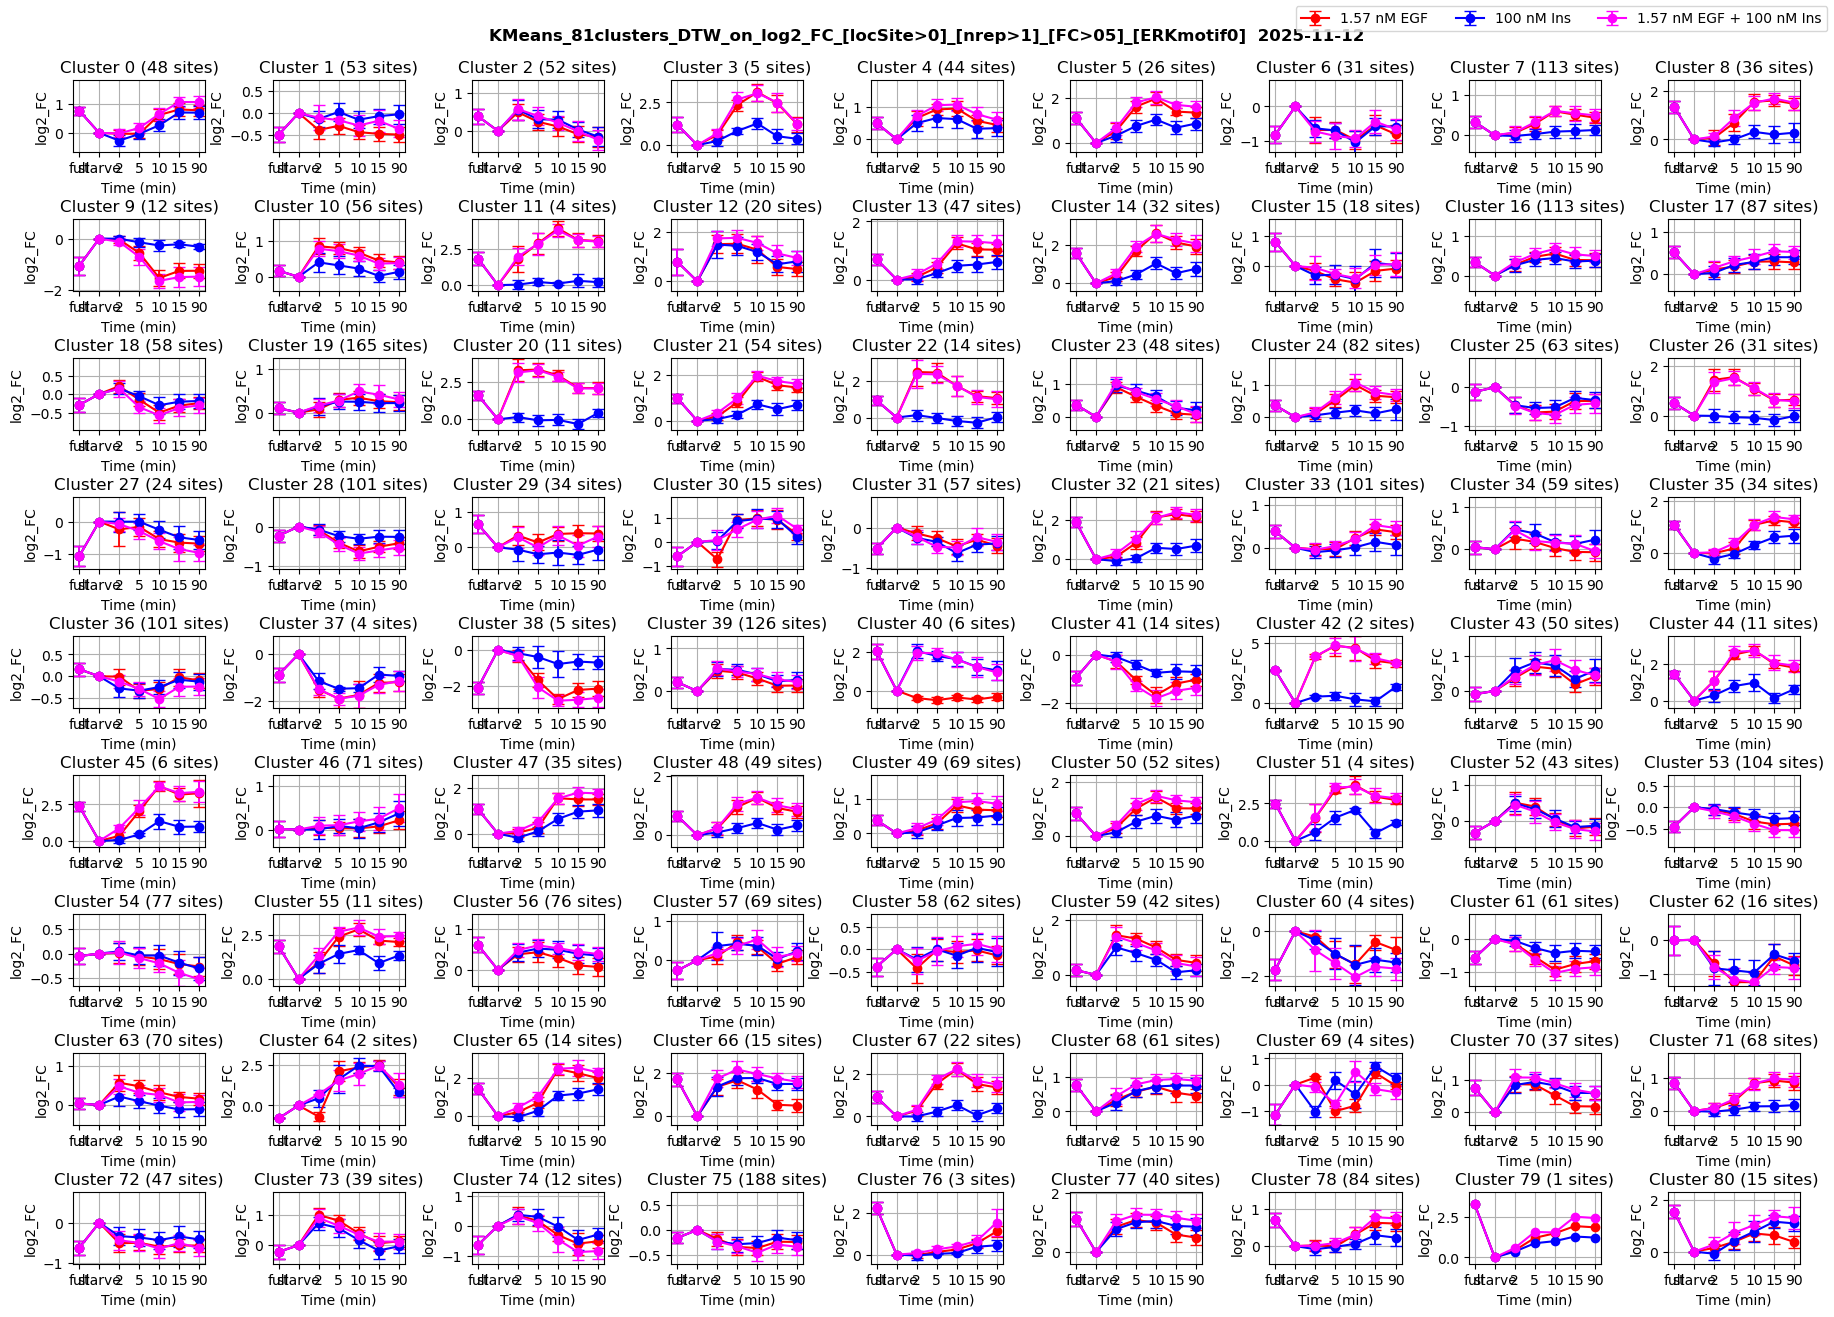

In [36]:
cluster_column = "KMeans_81clusters_DTW_on_log2_FC_[locSite>0]_[nrep>1]_[FC>05]_[ERKmotif0]"
clusters_plot(df=df_cluster,
              legend=['1.57 nM EGF', '100 nM Ins', '1.57 nM EGF + 100 nM Ins'],
              saving_path="",
              cluster_column = cluster_column,
              data_type = "log2_FC",
              plot_different_data = False,
              cluster_name="",
              saving_info="",
              y_lims_list=False,
              save_pdf=False,
              save_png=False,
              plot_close=False)

/Users/ignacionavascamacho/PycharmProjects/TMT_Data_analysis/utils.py:109: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by=['site'], inplace=True)


KMeans_81clusters_DTW_on_log2_FC_[locSite>0]_[nrep>1]_[FC>05]_[ERKmotif0]_group40_ Plot not saved


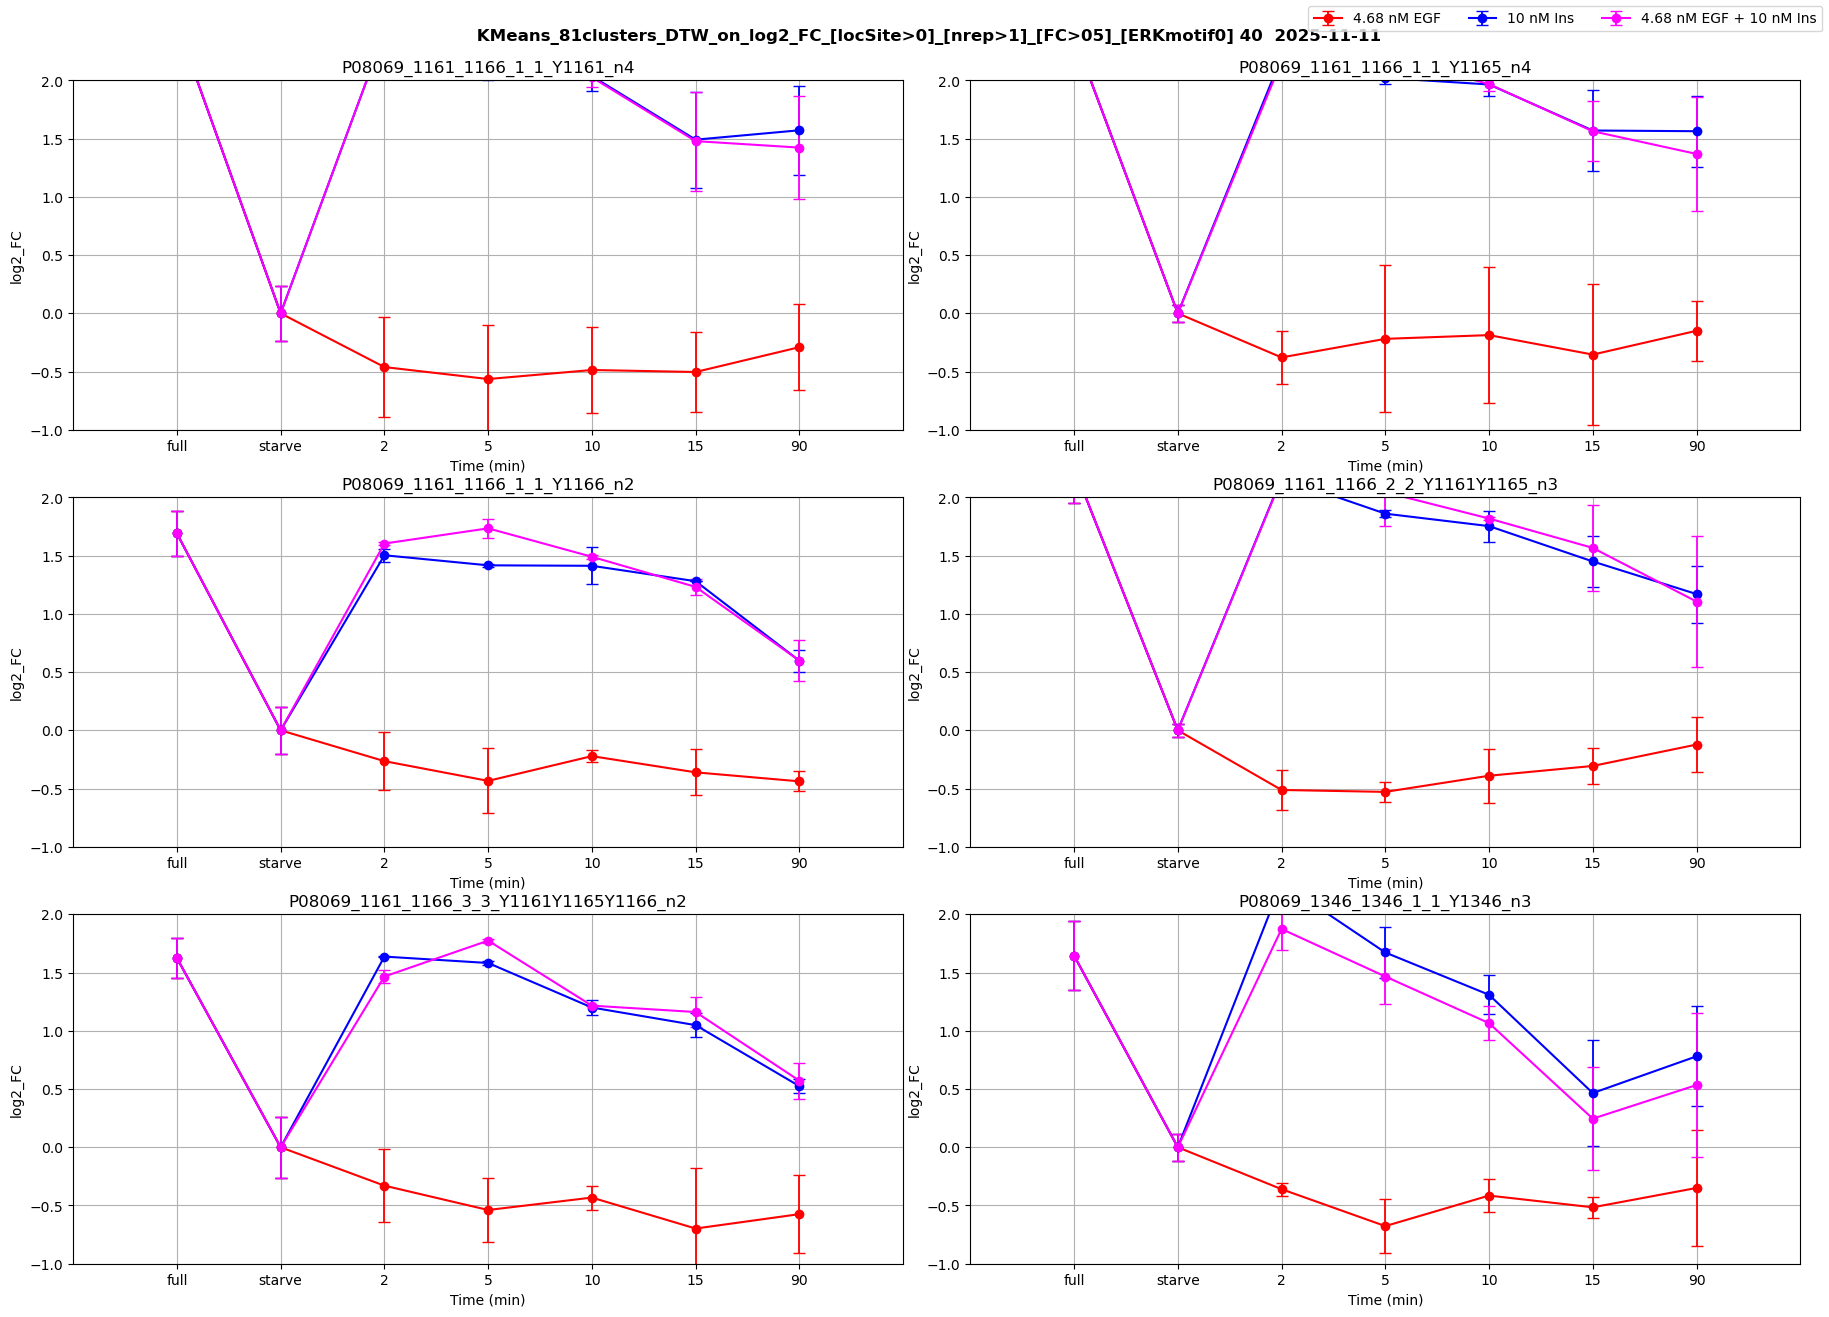

In [31]:
# cluster_column = cluster_column
cluster =40
plot_dataset_phosphosites(df = df_cluster,
                          cluster_column = cluster_column,
                          cluster_number = cluster,
                          data_type = "log2_FC",
                          legend=['4.68 nM EGF', '10 nM Ins', '4.68 nM EGF + 10 nM Ins'],
                          color_palette = ['r', 'b', 'fuchsia'],
                          saving_path="",
                          dataset_name="",
                          saving_info="",
                          plot_individually=False,
                          fit_y_lims=[-1,2],
                          save_pdf=False,
                          save_png=False,
                          plot_close=False
                          )

# checking = df_cluster.loc[df_cluster[cluster_column] == cluster]
# proteins = checking.protein_name.unique()
# uniprot_links_for(checking,proteins)
# proteins

In [28]:
checking = df_cluster.loc[df_cluster[cluster_column] == cluster]
proteins = checking.protein_name.unique().tolist()
uniprot_links_for(checking,proteins)

NameError: name 'cluster_column' is not defined

-

In [29]:
clustering1 = "KMeans_81clusters_DTW_on_log2_FC_[locSite>0]_[nrep>1]_[FC>05]"
clustering2 = "KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>05]"

subset = df_cluster.loc[df_cluster["protein_Id"] == "Q9H1B7"][["protein_name", "site", clustering1, clustering2]]
subset = subset.loc[subset[clustering1] != 999]

subset

,protein_name,site,KMeans_81clusters_DTW_on_log2_FC_[locSite>0]_[nrep>1]_[FC>05],KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>05]
38774,IRF2BPL,Q9H1B7_2_9_1_1_S7~SAAQVsSSR,61,52
38780,IRF2BPL,Q9H1B7_334_338_1_1_S334~RPGsVSSTDQER,27,56
38806,IRF2BPL,Q9H1B7_657_665_3_1_S657~RNsSSPVSPASVPGQR,72,14


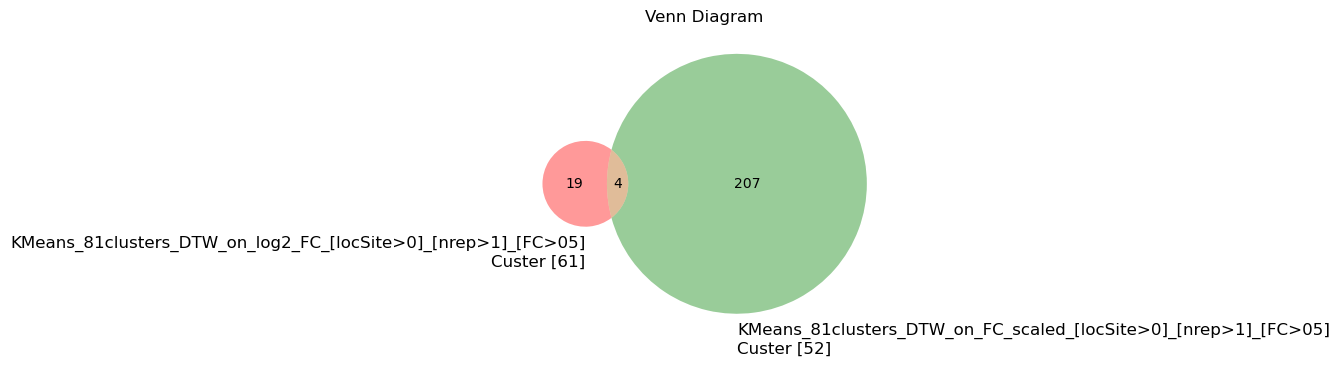

In [32]:
from matplotlib import pyplot as plt
from matplotlib_venn import venn2

site = "Q9H1B7_2_9_1_1_S7~SAAQVsSSR"
clustering1_number = subset.loc[subset["site"] == site][clustering1].values.tolist()
clustering2_number = subset.loc[subset["site"] == site][clustering2].values.tolist()

# clustering1_number = [5]
# clustering2_number = [30]

clustering_set_1_log2FC = set(df_cluster.loc[df_cluster[clustering1] == clustering1_number[0]].site.tolist())

clustering_set_2_FCscaled = set(df_cluster.loc[df_cluster[clustering2] == clustering2_number[0]].site.tolist())

# Create a Venn diagram
plt.figure(figsize=(6, 4))
venn2([clustering_set_1_log2FC, clustering_set_2_FCscaled], set_labels=(f"{clustering1}\nCuster {clustering1_number}", f"{clustering2}\nCuster {clustering2_number}"))
plt.title("Venn Diagram")
plt.show()


{'Q15418_359_369_3_3_T359S363S369~tPKDsPGIPPsAGAHQLFR', 'Q9H1B7_2_9_1_1_S7~SAAQVsSSR', 'P15924_2603_2625_2_1_S2606~NLTIRsSSFSDTLEESSPIAAIFDTENLEK', 'O94761_27_38_1_1_S27~GRRPsQDDVEAAPEETR;RPsQDDVEAAPEETR'}
Sared sites beween 
[KMeans_81clusters_DTW_on_log2_FC_[locSite>0]_[nrep>1]_[FC>05] cluster_61] and [KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>05] cluster_52]_group_ Plot not saved


/Users/ignacionavascamacho/PycharmProjects/TMT_Data_analysis/utils.py:105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by=['site'], inplace=True)


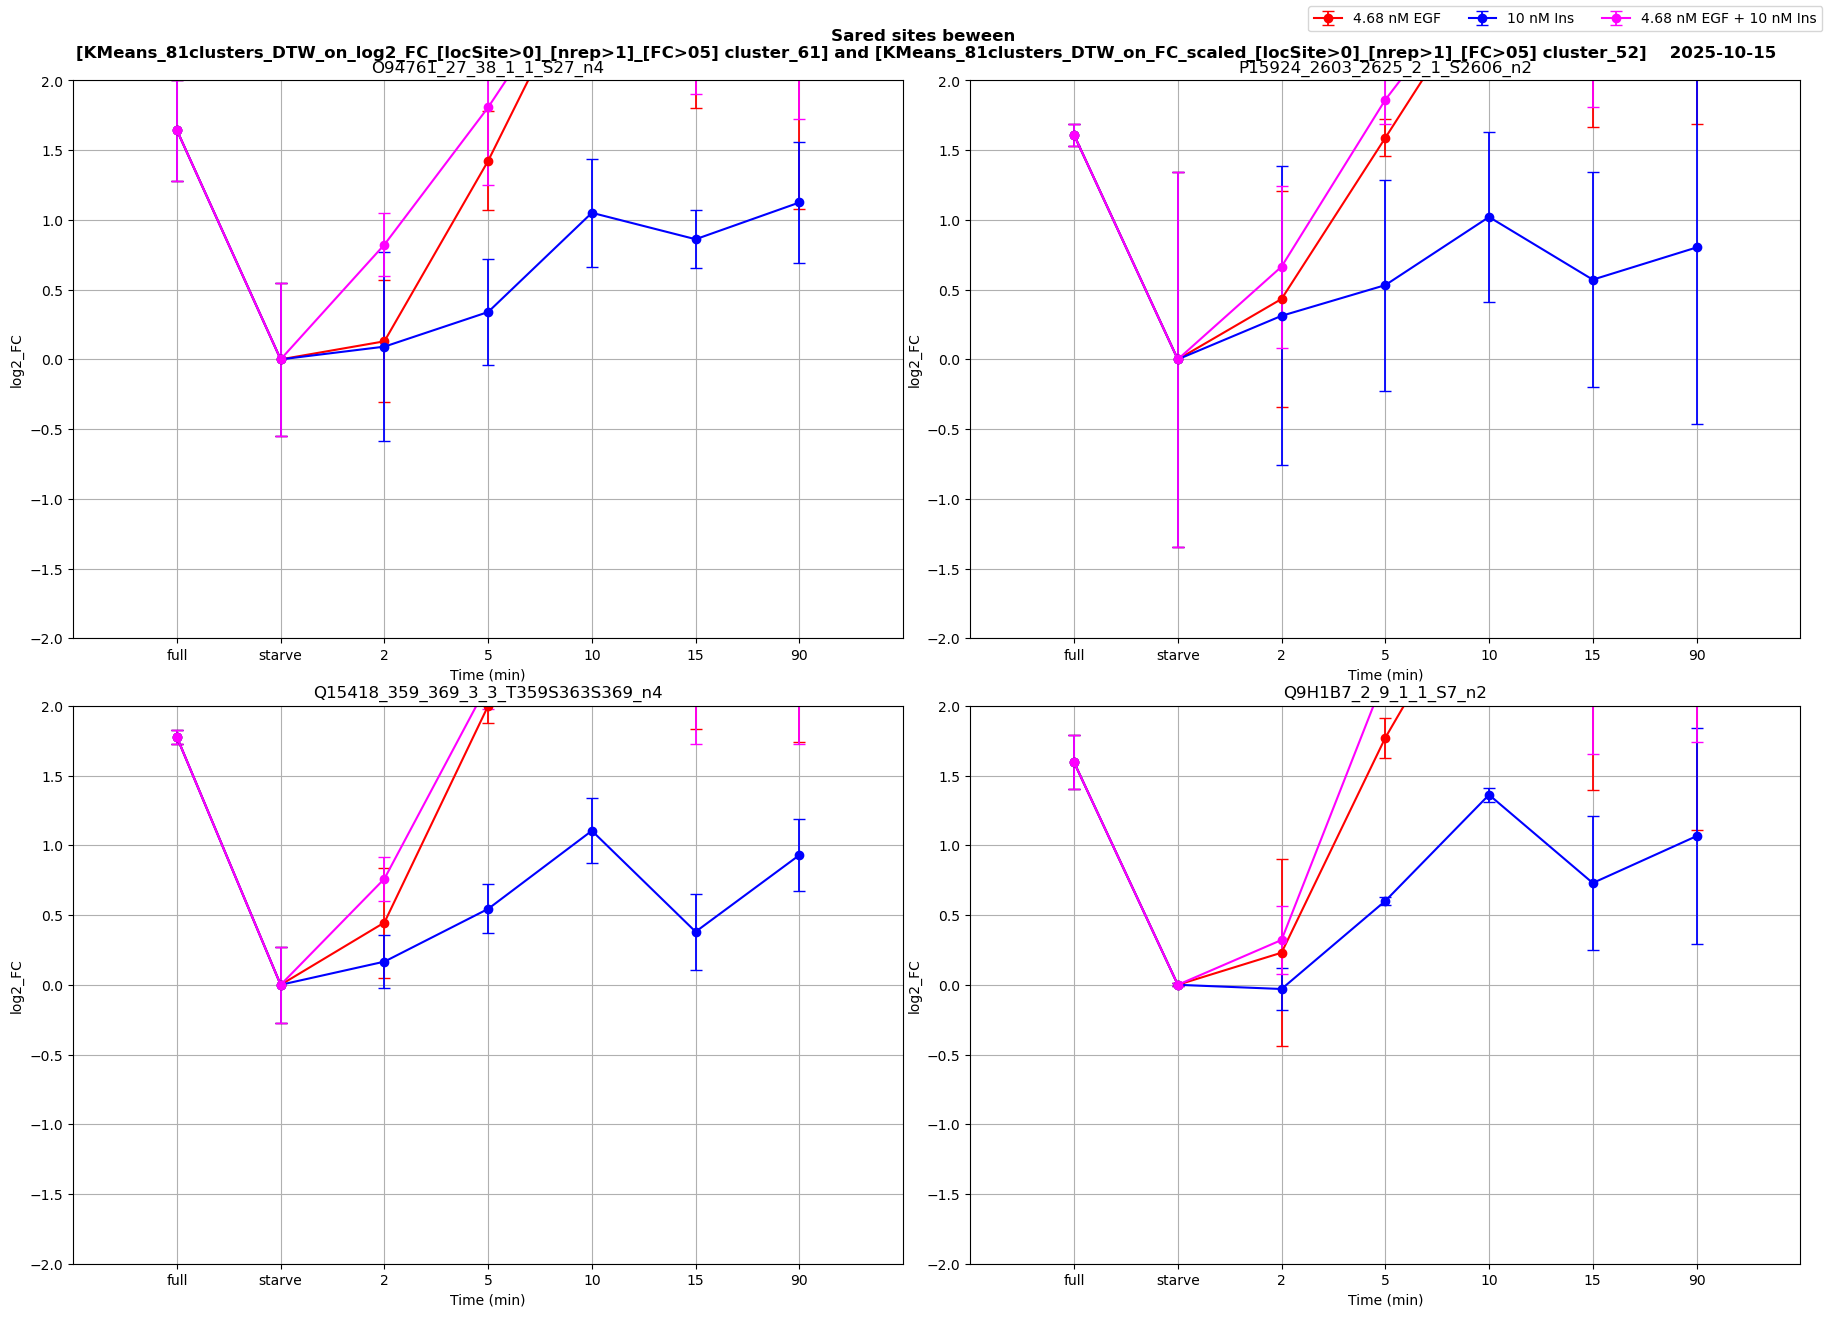

In [125]:
shared_sites = clustering_set_1_log2FC & clustering_set_2_FCscaled
print(shared_sites)

shared_sites_subset = df_cluster.loc[df_cluster["site"].isin(shared_sites)]
plot_dataset_phosphosites(df = shared_sites_subset,
                          cluster_column = "",
                          cluster_number = "",
                          data_type = "log2_FC",
                          legend=['4.68 nM EGF', '10 nM Ins', '4.68 nM EGF + 10 nM Ins'],
                          color_palette = ['r', 'b', 'fuchsia'],
                          saving_path="",
                          dataset_name= f"Sared sites beween \n[{clustering1} cluster_{clustering1_number[0]}] and [{clustering2} cluster_{clustering2_number[0]}]",
                          saving_info="",
                          plot_individually=False,
                          fit_y_lims=[-2,2],
                          save_pdf=False,
                          save_png=False,
                          plot_close=False
                          )
proteins = shared_sites_subset.protein_name.unique()
uniprot_links_for(shared_sites_subset, protein_list=proteins)

/Users/ignacionavascamacho/PycharmProjects/TMT_Data_analysis/utils.py:105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by=['site'], inplace=True)


KMeans_81clusters_DTW_on_log2_FC_[locSite>0]_[nrep>1]_[FC>05] cluster 61KMeans_81clusters_DTW_on_log2_FC_[locSite>0]_[nrep>1]_[FC>05]_group61_ Plot not saved


/Users/ignacionavascamacho/PycharmProjects/TMT_Data_analysis/utils.py:105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by=['site'], inplace=True)


KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>05] cluster 52KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>05]_group52_ Plot not saved


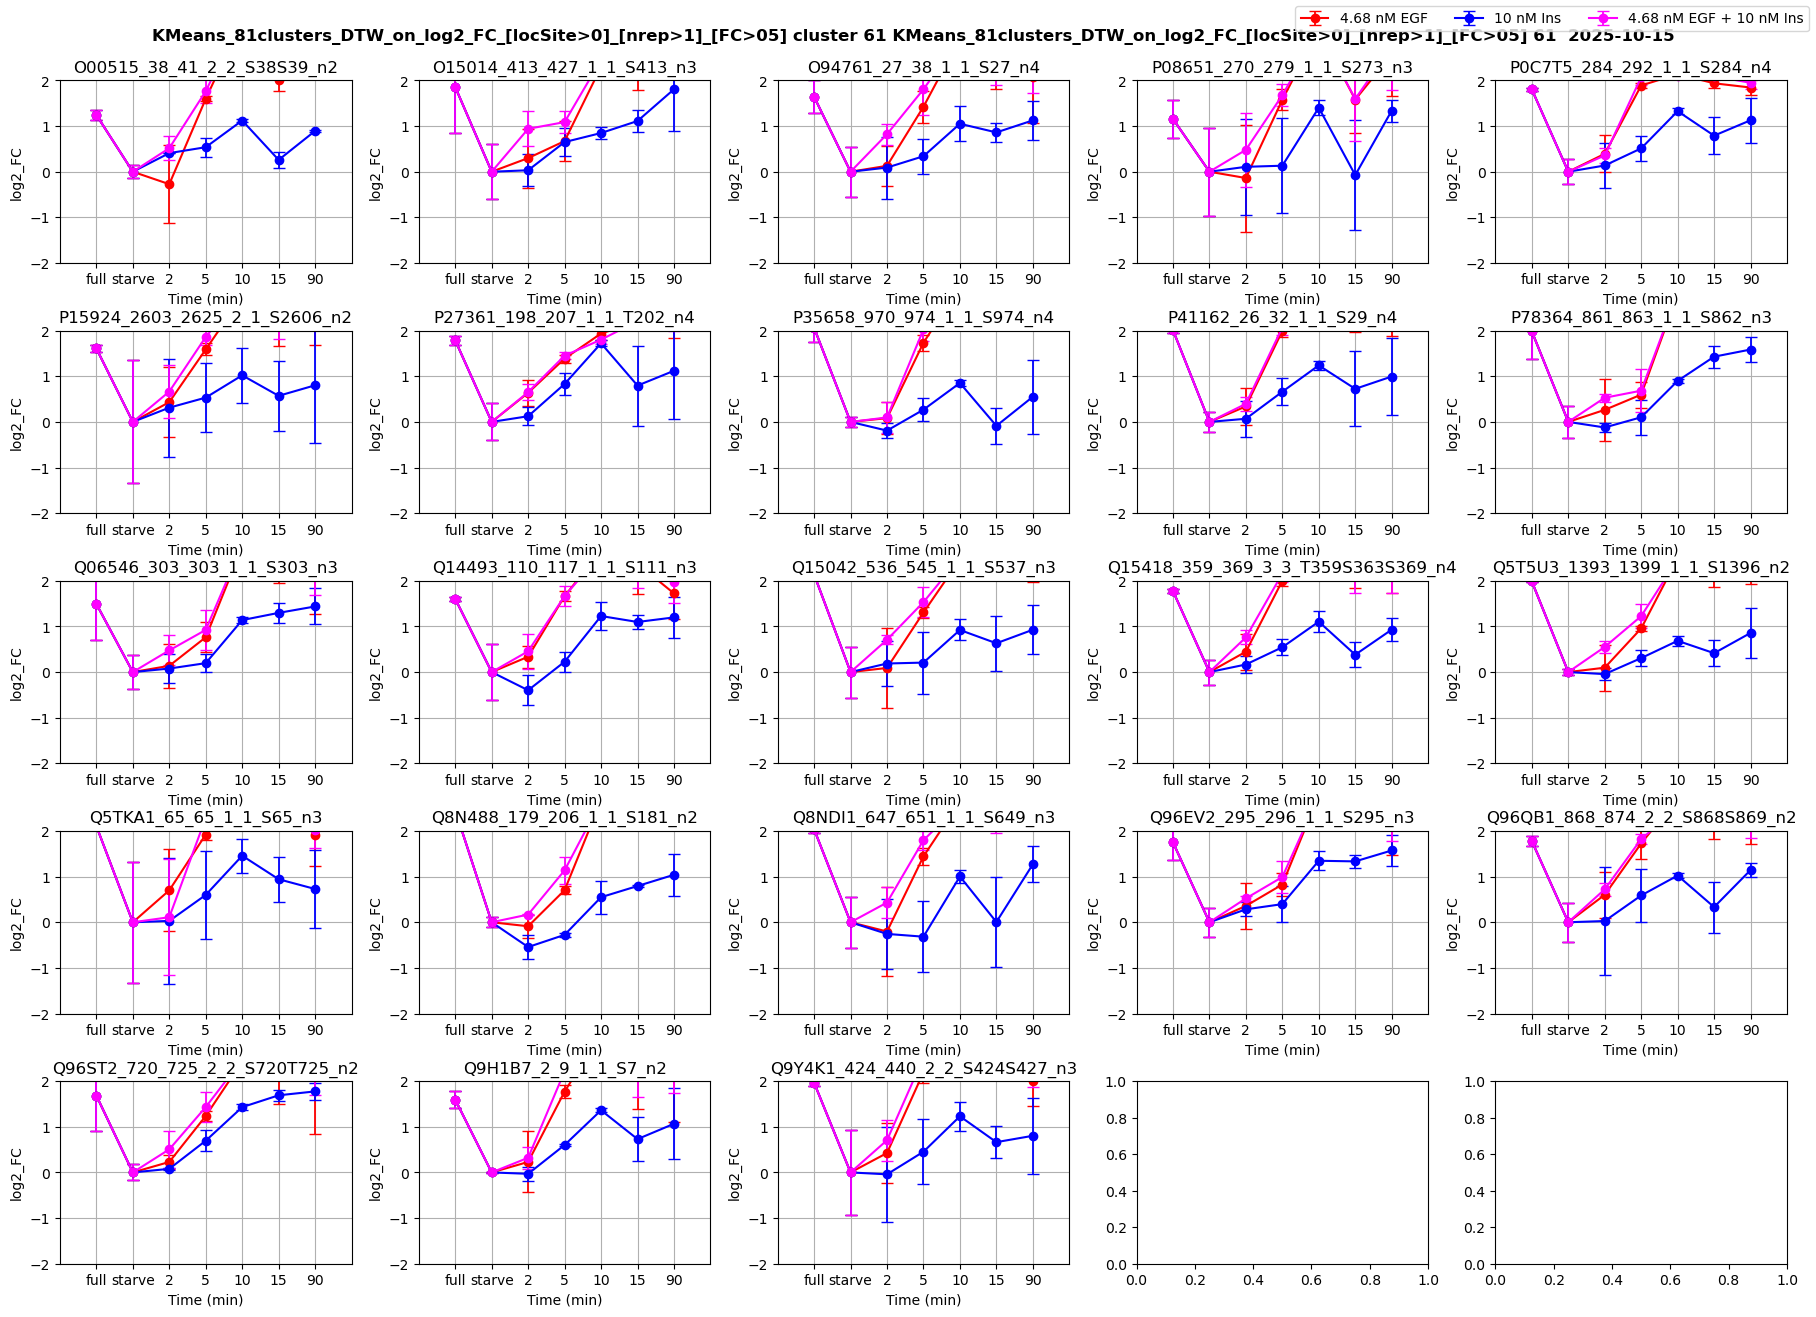

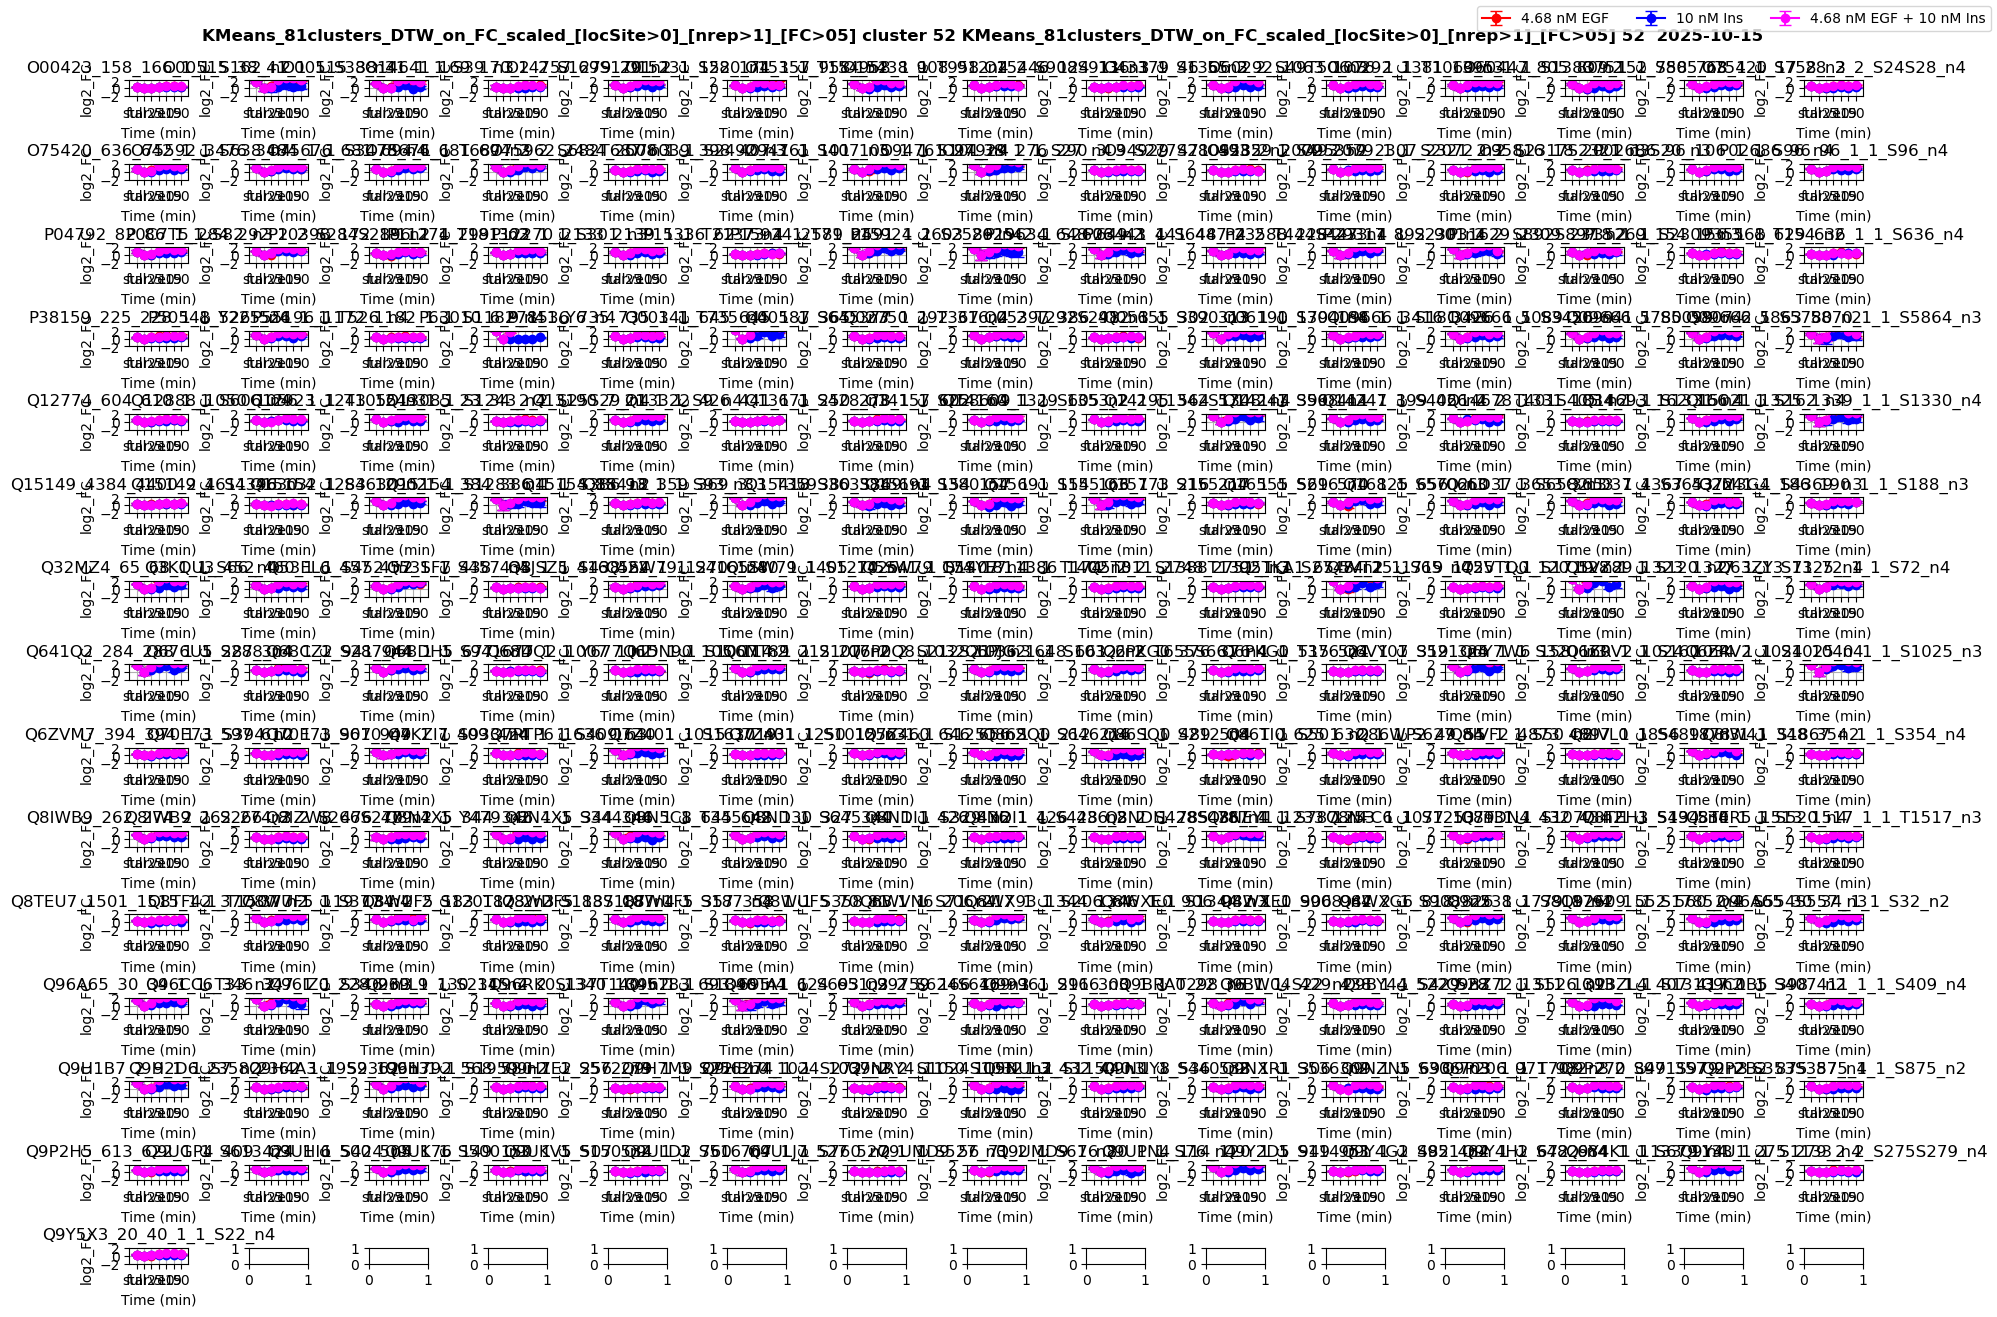

In [126]:
columns = [clustering1, clustering2]
clusters = [clustering1_number[0], clustering2_number[0]]

for i in range(len(columns)):
    plot_dataset_phosphosites(df = df_cluster,
                          cluster_column = columns[i],
                          cluster_number = clusters[i],
                          data_type = "log2_FC",
                          legend=['4.68 nM EGF', '10 nM Ins', '4.68 nM EGF + 10 nM Ins'],
                          color_palette = ['r', 'b', 'fuchsia'],
                          saving_path="",
                          dataset_name= f"{columns[i]} cluster {clusters[i]}",
                          saving_info="",
                          plot_individually=False,
                          fit_y_lims=[-2,2],
                          save_pdf=False,
                          save_png=False,
                          plot_close=False
                          )


# KShape clustering


In [39]:
def tslearn_clustering_KShape(df_to_cluster,
                              data_type,
                              number_of_clusters,
                              max_iterations = 1000,
                              # metric='euclidean',
                              verbose = True ):

    column_names = df_to_cluster.columns.tolist()
    column_selection = [element for element in column_names if f"{data_type}" in element]

    multivariate_df, names_of_myseries = reshape_df(df = df_to_cluster, time_series = column_selection, dimensions = 3, len_time_serie = 7, transpose=False)
    print(f"\nThe size of the dataset is {multivariate_df.shape}")

    clustering = KShape(n_clusters=number_of_clusters, max_iter=max_iterations, n_init = 10, verbose=verbose, random_state=0).fit(multivariate_df)

    df_to_cluster[f"{data_type}_KShape_clusters"] = clustering.labels_

    return df_to_cluster

In [42]:
b = tslearn_clustering_KShape(df_to_cluster = subdata_f_score,
                          data_type = "log2_FC",
                          number_of_clusters = 81,
                          max_iterations = 100,
                          verbose = True )

KeyError: '      protein_Id                                        description  \\\n18        A0AVK6  Transcription factor E2F8 OS=Homo sapiens OX=9...   \n28        A0FGR8  Extended synaptotagmin-2 OS=Homo sapiens OX=96...   \n29        A0FGR8  Extended synaptotagmin-2 OS=Homo sapiens OX=96...   \n60        A0MZ66  Shootin-1 OS=Homo sapiens OX=9606 GN=SHTN1 PE=...   \n74        A1L170  Uncharacterized protein C1orf226 OS=Homo sapie...   \n...          ...                                                ...   \n49618     Q9H7Z6  Histone acetyltransferase KAT8 OS=Homo sapiens...   \n49625     Q9H9L7  Akirin-1 OS=Homo sapiens OX=9606 GN=AKIRIN1 PE...   \n49649     Q9NQR1  N-lysine methyltransferase KMT5A OS=Homo sapie...   \n49660     Q9NVM9  Integrator complex subunit 13 OS=Homo sapiens ...   \n49741     Q9Y2T1  Axin-2 OS=Homo sapiens OX=9606 GN=AXIN2 PE=1 SV=2   \n\n      protein_name                                     Peptide  \\\n18            E2F8                             EGSQGEP

In [227]:
clusters_plot(df=b,
              legend=['1.57 nM EGF', '100 nM Ins', '1.57 nM EGF + 100 nM Ins'],
              saving_path="",
              cluster_column = "log2_FC_clusters",
              data_type = "log2_FC",
              plot_different_data = False,
              cluster_name="",
              saving_info="",
              y_lims_list=False,
              save_pdf=False,
              save_png=False,
              plot_close=True
              )

 Plot not saved


/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.8/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning:

All-NaN axis encountered

/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.8/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning:

All-NaN axis encountered



In [226]:
plot_dataset_phosphosites(df = b,
                          cluster_column = "log2_FC_clusters",
                          cluster_number = 24,
                          data_type = "log2_FC",
                          legend=['4.68 nM EGF', '10 nM Ins', '4.68 nM EGF + 10 nM Ins'],
                          color_palette = ['r', 'b', 'fuchsia'],
                          saving_path="",
                          dataset_name="",
                          saving_info="",
                          plot_individually=False,
                          fit_y_lims=[-1,1],
                          save_pdf=False,
                          save_png=False,
                          plot_close=True
                          )

/Users/ignacionavascamacho/PycharmProjects/TMT_Data_analysis/utils.py:103: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



log2_FC_clusters_group24_ Plot not saved


-------------------------------
# Kernnel clusterting


In [43]:
dataframe = df_2_hME1_scaled.copy()
######### Phospho site localization
# > 0 means localized site (at least one)
# = 0 means no localized
subdata = dataframe.loc[dataframe["localized_sites"] > 0]

######### Phospho site replicates
# > 1 means at least 2 reps
# > 2 means at least 3 reps
subdata = subdata.loc[subdata["n_rep"] > 1]

######### ERK motif
# 0 means no ERK motif
# 1 means yes ERK motif
subdata_erk_motif = subdata.loc[subdata["ERK_motif"] == 1]

######### functional score
subdata_f_score = subdata.loc[subdata["functional_score"] > 0.5]


combined = subdata_erk_motif.loc[subdata_erk_motif["functional_score"] > 0.5]
# ######### ms lit
# subdata_ms_lit = subdata.loc[subdata["ms_lit"] > 0.5]

In [44]:
print(f"Length of original dataframe = {len(dataframe)}")
# Filter based in profile parameter
subdata = subdata.copy()

print(f"len(subdata) [(localized_sites > 0) & (n_rep > 1)] = {len(subdata)}")
##################### FC threshold
data_type = "log2_FC"  #
column_names = subdata.columns.tolist()
column_selection = [element for element in column_names if element.startswith(f"{data_type}") and "full" not in element]

mask = subdata[column_selection].abs().max(axis=1) > 0.5
subdata_fc = subdata.loc[mask].copy()
print(f"len(subdata_fc) [FC >0.5] = {len(subdata_fc)}")

print(f"Clustering based on {column_selection}")
# data_type = "log2_FC" #
# column_names = subdata.columns.tolist()
# column_selection = [element for element in column_names if element.startswith(f"{data_type}") and "full" not in element]
#
# mask = subdata_fc[column_selection].abs().max(axis=1) > 0.3
# subdata_fc_2 = subdata_fc.loc[mask].copy()
# print(f"len(subdata_fc_2) [0.3 < FC < 0.5)]= {len(subdata_fc_2)}")
# subdata_fc
#################### PVALUE
# data_type = "FC_pvalue" #data type over which I want to do the filtering and the clustering
#
# column_names = subdata.columns.tolist()
# column_selection = [element for element in column_names if f"{data_type}" in element and "full" not in element and "starve" not in element]
# neglog10 = -np.log10(subdata[column_selection])
# mask = (neglog10 > 2).any(axis=1)
# # mask = subdata[column_selection].max(axis=1) > 0.05 #dont understand why i have to it this way
# subdata_pv = subdata.loc[mask].copy()
# print(len(subdata_pv))

Length of original dataframe = 50014
len(subdata) [(localized_sites > 0) & (n_rep > 1)] = 24268
len(subdata_fc) [FC >0.5] = 5614
Clustering based on ['log2_FC_EGF_starve', 'log2_FC_EGF_2', 'log2_FC_EGF_5', 'log2_FC_EGF_10', 'log2_FC_EGF_15', 'log2_FC_EGF_90', 'log2_FC_INS_starve', 'log2_FC_INS_2', 'log2_FC_INS_5', 'log2_FC_INS_10', 'log2_FC_INS_15', 'log2_FC_INS_90', 'log2_FC_EGFnINS_starve', 'log2_FC_EGFnINS_2', 'log2_FC_EGFnINS_5', 'log2_FC_EGFnINS_10', 'log2_FC_EGFnINS_15', 'log2_FC_EGFnINS_90']


In [20]:
def reshape_df(df,
               time_series,
               dimensions,
               len_time_serie,
               transpose = False):
    '''Reshape dataframe so it is multivariate format. Return the dataframe in numpy format so can be used, and list with the names of myseries'''

    sub_df = df[time_series].copy()
    mySeries = sub_df.to_numpy()
    namesofMySeries = df["site"]

    multivariate_shape = (len(df), dimensions, len_time_serie)
    multivariate_df = np.reshape(mySeries, multivariate_shape)
    if transpose == True:
        multivariate_df = multivariate_df.transpose(0, 2, 1)

    return multivariate_df, namesofMySeries

In [45]:
data_type = "log2_FC"

column_names = subdata_fc.columns.tolist()
column_selection = [element for element in column_names if f"{data_type}" in element]

X, y = reshape_df(df = subdata_fc, time_series = column_selection, labels = "site", dimensions = 3, len_time_serie = 7, transpose = False)
print(f"The size of the dataset is {X.shape}, labels: {y.shape}")

X_transposed, y = reshape_df(df = subdata_fc, time_series = column_selection, labels = "site",  dimensions = 3, len_time_serie = 7, transpose = True)
print(f"transposed matrix has shape {X_transposed.shape}, labels: {y.shape}")


The size of the dataset is (5614, 3, 7), labels: (5614,)
transposed matrix has shape (5614, 7, 3), labels: (5614,)


In [25]:
from tslearn.clustering import KernelKMeans
from sklearn.model_selection import train_test_split

#not transposed data
# X_t ,X_v , yt, yv = train_test_split(X_transposed , y , stratify=y)
# print(f"For the not trasnformed data, sizes are:"
#       f"\n train set len: {len(X_t)}"
#       f"\n validation set len:  {len(X_v)}")

#transposed data
# Xt_t ,Xt_v , yt, yv = train_test_split(X , y , stratify=y)
# print(f"For the not trasnformed data, sizes are:"
#       f"\n train set len: {len(Xt_t)}"
#       f"\n validation set len:  {len(Xt_v)}")
seed = 0
gak_km = KernelKMeans(n_clusters = 25,
                      kernel="gak",
                      kernel_params={"sigma": "auto"},
                      n_init=20,
                      verbose=True,
                      random_state=seed)

clusters_predicted = gak_km.fit_predict(X)
# 8 mins for 5600 sites

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 1799 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 2449 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 3199 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 4049 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 4999 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 6049 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 7199 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 8449 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 9799 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 11249 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 12799 tasks      | elapsed:    0.3s
[Parallel(

Init 1
6721.812 --> 3405.139 --> 2906.696 --> 2836.024 --> 2816.546 --> 2780.484 --> 2736.687 --> 2704.646 --> 2690.367 --> 2687.400 --> 2683.998 --> 2683.911 --> 2688.082 --> 2689.281 --> 2691.002 --> 2691.842 --> 2692.466 --> 2693.796 --> 2696.162 --> 2698.041 --> 2698.447 --> 2700.365 --> 2700.860 --> 2701.717 --> 2702.000 --> 2703.292 --> 2704.130 --> 2703.679 --> 2706.342 --> 2707.742 --> 2708.394 --> 2709.554 --> 2710.468 --> 2712.558 --> 2713.479 --> 2713.998 --> 2715.806 --> 2717.657 --> 2719.387 --> 2720.294 --> 2723.277 --> 2725.140 --> 2725.035 --> 2725.382 --> 2727.937 --> 2730.471 --> 2732.169 --> 2733.482 --> 2734.485 --> 2734.079 --> 
Init 2
Resumed because of empty cluster
Init 2
6796.600 --> 3235.093 --> 2852.931 --> 2797.450 --> 2775.977 --> 2761.257 --> 2753.658 --> 2747.365 --> 2742.714 --> 2734.917 --> 2729.519 --> 2726.978 --> 2729.437 --> 2730.178 --> 2728.408 --> 2723.516 --> 2721.320 --> 2716.861 --> 2712.873 --> 2711.308 --> 2709.724 --> 2707.672 --> 2707.671 

In [26]:
print(len(clusters_predicted), clusters_predicted.shape)
# clusters_predicted

5614 (5614,)


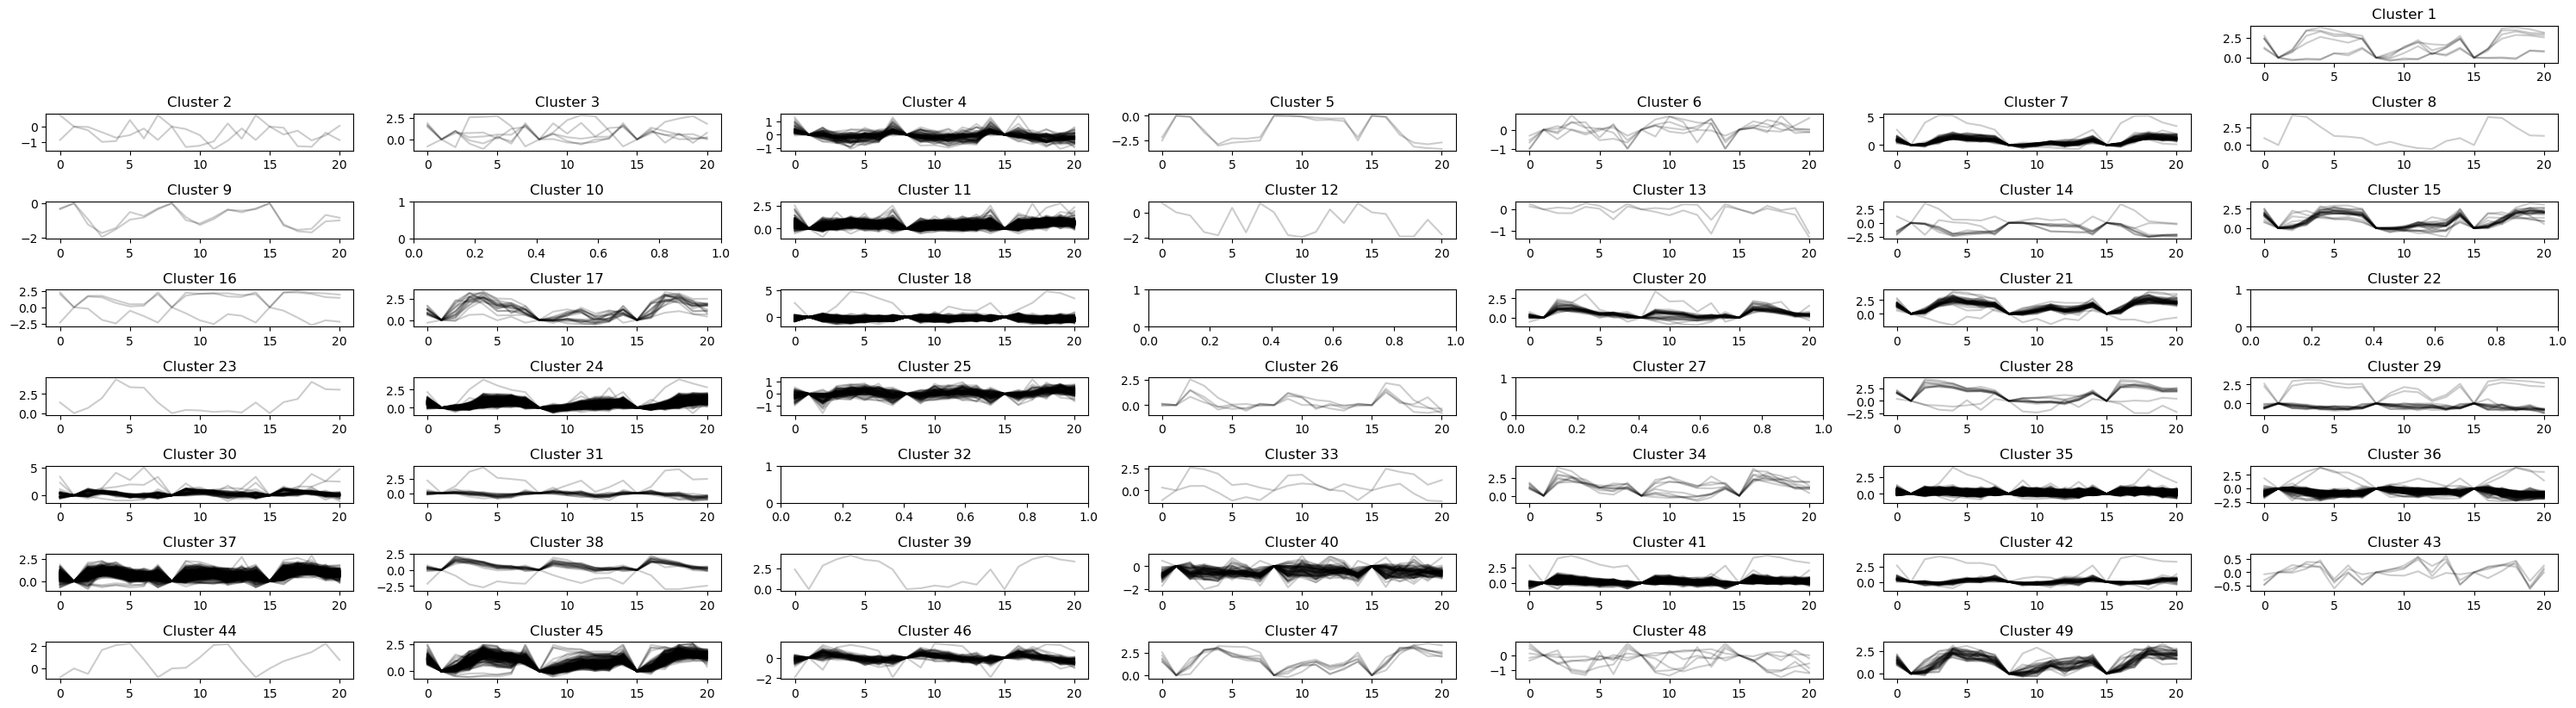

In [23]:
plt.figure(figsize=(30,50))
for yi in range(49):
    plt.subplot(49, 7, 7 + yi)
    for xx in X[clusters_predicted == yi]:
        plt.plot(xx.ravel(), "k-", alpha=.2)
    # plt.xlim(0, sz)
    # plt.ylim(-4, 4)
    plt.title("Cluster %d" % (yi + 1))

plt.tight_layout()
plt.show()

In [38]:
def clusters_plot(df,
                  legend=list,
                  saving_path=str,
                  cluster_column = str,
                  cluster_name="",
                  data_type = str,
                  plot_different_data = False,
                  saving_info="",
                  save_pdf=False,
                  save_png=False,
                  plot_close=False,
                  y_lims_list=False):
    '''Take a dataset that include an extra column for the "cluster" the site belongs to. Calculates the mean for each
     time point and plot it. This way you can see the average curves of each cluster.'''
    if type(df) == pd.DataFrame:
        pass
    else:
        df = pd.read_excel(df)

    if save_pdf == False and save_png == False:
        pass
    else:
        if not os.path.exists(saving_path):
            print("Creating saving folder")
            os.makedirs(saving_path)

    clusters = list(set(df[cluster_column]))
    if 999 in clusters:
        clusters.remove(999)
    if data_type not in cluster_column and plot_different_data == False:
            print("Remember to plot the same data_type used to make the clustering")
    else:
        if type(clusters[0]) == int:
            sorted_clusters = sorted(clusters)
        else:
            sorted_clusters = sorted(clusters, key=lambda x: int(x.split()[1]))

        # Geting some basic information and parameters for the plots
        n_cluster = len(sorted_clusters)
        sqrt_n_c = int(np.ceil(np.sqrt(n_cluster)))
        empty_plots = (sqrt_n_c * sqrt_n_c) - n_cluster

        # Avoid getting rows with empty plots
        if empty_plots >= sqrt_n_c:
            sqrt_n_c_X = sqrt_n_c - 1
        else:
            sqrt_n_c_X = sqrt_n_c

        i_list = list(range(sqrt_n_c))
        i_c = 0
        j_list = list(range(sqrt_n_c_X))
        j_c = 0

        # Seting subplots aprameters
        fig, ax = plt.subplots(sqrt_n_c, sqrt_n_c_X, figsize=(18, 13))  # figsize=(7, 4) figsize=(18, 13) figsize=(29.7, 21)
        fig.tight_layout(w_pad=1.75, h_pad=3)
        plt.subplots_adjust(top=0.94)  # percentage of the figure that the plots are using

        # time points of the dataset
        column_names = df.columns.tolist()
        time_points_previous = [element for element in column_names if f"log2_FC_EGF_" in element] # this could be any set of columns that have the time points
        time_points = [s.split("_")[-1] for s in time_points_previous]

        EGF_matching_cols = [col for col in df.columns if any(f"{data_type}_EGF_{t}" in col for t in time_points)]
        INS_matching_cols = [col for col in df.columns if any(f"{data_type}_INS_{t}" in col for t in time_points)]
        EGFnINS_matching_cols = [col for col in df.columns if any(f"{data_type}_EGFnINS_{t}" in col for t in time_points)]

        for cluster in sorted_clusters:
            # Create sub-dataframe with only the protein we are interested in. If the protein doesn't exist in the dataframe skip code
            sub_df = df.loc[df[cluster_column] == cluster].copy()

            # Calculate averages for each time points of the phosphosites in the cluster
            EGF_means = [sub_df[col].mean() for col in EGF_matching_cols]
            INS_means = [sub_df[col].mean() for col in INS_matching_cols]
            EGFnINS_means = [sub_df[col].mean() for col in EGFnINS_matching_cols]

            # Calculate standard deviations for each time points of the phosphosites in the cluster
            EGF_err = [sub_df[col].std() for col in EGF_matching_cols]
            INS_err = [sub_df[col].std() for col in INS_matching_cols]
            EGFnINS_err = [sub_df[col].std() for col in EGFnINS_matching_cols]

            groups = [EGF_means, INS_means, EGFnINS_means]
            groups_sd = [EGF_err, INS_err, EGFnINS_err]
            colors = ['r', 'b', 'fuchsia']

            for c in range(3):
                ax[i_list[i_c], j_list[j_c]].errorbar(x=time_points, y=groups[c],
                                                      yerr=groups_sd[c], marker='o', color=colors[c], capsize=4,
                                                      elinewidth=1.3)

            ax[i_list[i_c], j_list[j_c]].set_xlabel("Time (min)")
            ax[i_list[i_c], j_list[j_c]].set_ylabel(f"{data_type}")
            ax[i_list[i_c], j_list[j_c]].grid()

            ax[i_list[i_c], j_list[j_c]].set_title(f"Cluster {cluster} ({len(sub_df)} sites)")
            ax[i_list[i_c], j_list[j_c]].set_ylim(min(min(groups)) - 0.3 * 1.3, max(max(groups)) + 0.5 * 1.5)
            if type(y_lims_list) == list:
                ax[i_list[i_c], j_list[j_c]].set_ylim(y_lims_list[0], y_lims_list[1])


            if j_c == len(j_list) - 1:
                j_c = 0
                i_c = i_c + 1
            else:
                j_c = j_c + 1

        fig.legend(labels=legend, loc="upper right", ncol=len(groups))
        fig.suptitle(f"{cluster_column} {cluster_name} {date.today()}", weight='bold')

        # Saving the plot
        if save_pdf == True:
            plt.savefig(f"{saving_path}/{cluster_name}{saving_info}.pdf")
            print(f"{cluster_name}{saving_info} Plot saved as PDF")
        if save_png == True:
            plt.savefig(f"{saving_path}/{cluster_name}{saving_info}.png")
            print(f"{cluster_name}{saving_info} Plot saved as PNG")
        if save_pdf == False and save_png == False:
            print(f"{cluster_name}{saving_info} Plot not saved")
        if plot_close == True:
            plt.close()

 Plot not saved


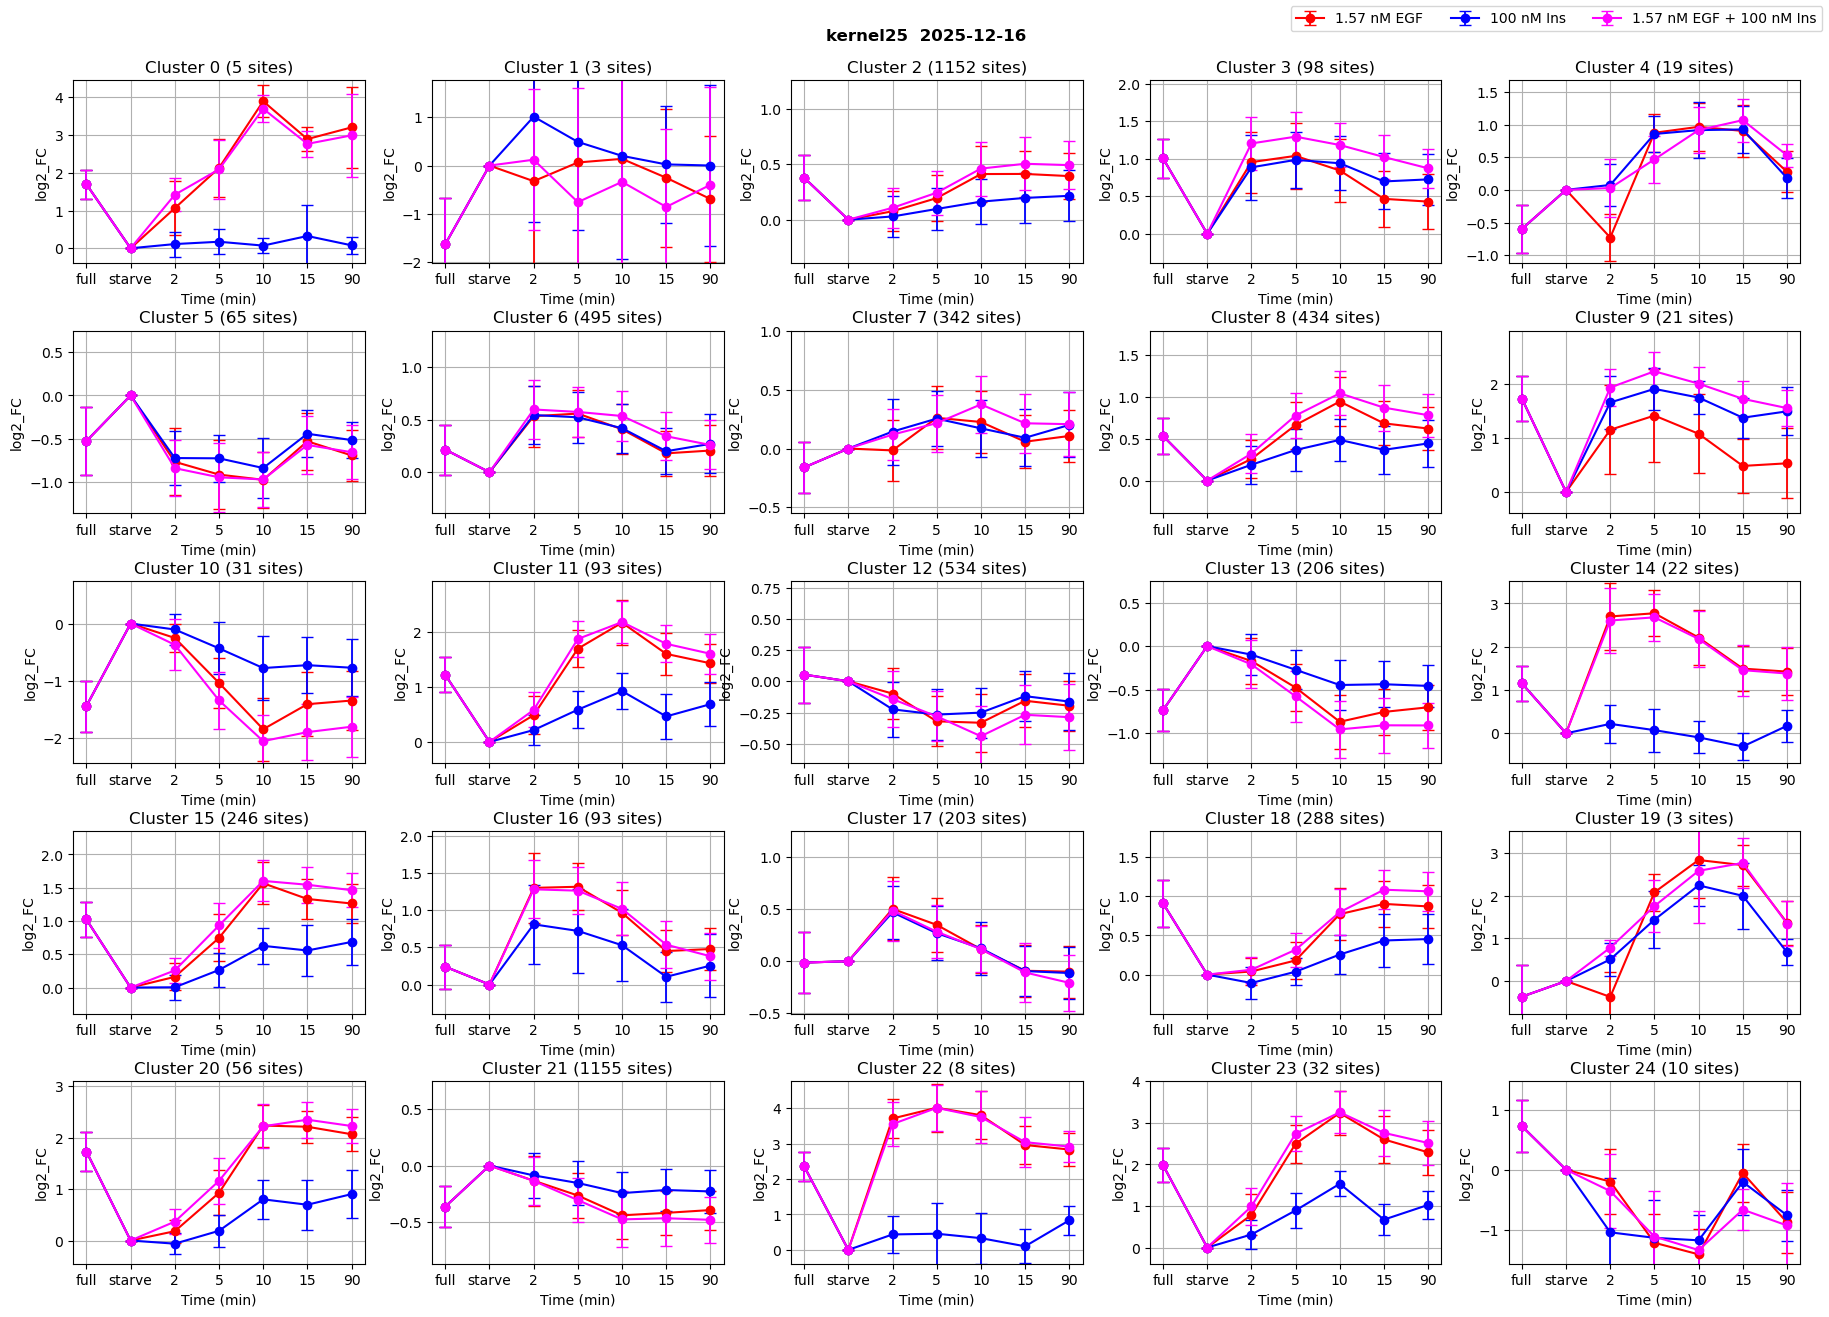

In [27]:
cluster_column_name = "kernel25"
subdata_fc[f"{cluster_column_name}"] == clusters_predicted
subdata_fc

cluster_column = cluster_column_name
clusters_plot(df=subdata_fc,
              legend=['1.57 nM EGF', '100 nM Ins', '1.57 nM EGF + 100 nM Ins'],
              saving_path="",
              cluster_column = cluster_column,
              data_type = "log2_FC",
              plot_different_data = True,
              cluster_name="",
              saving_info="",
              y_lims_list=False,
              save_pdf=False,
              save_png=False,
              plot_close=False)

/Users/ignacionavascamacho/PycharmProjects/TMT_Data_analysis/utils.py:111: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by=['site'], inplace=True)


kernel25_group23_ Plot not saved


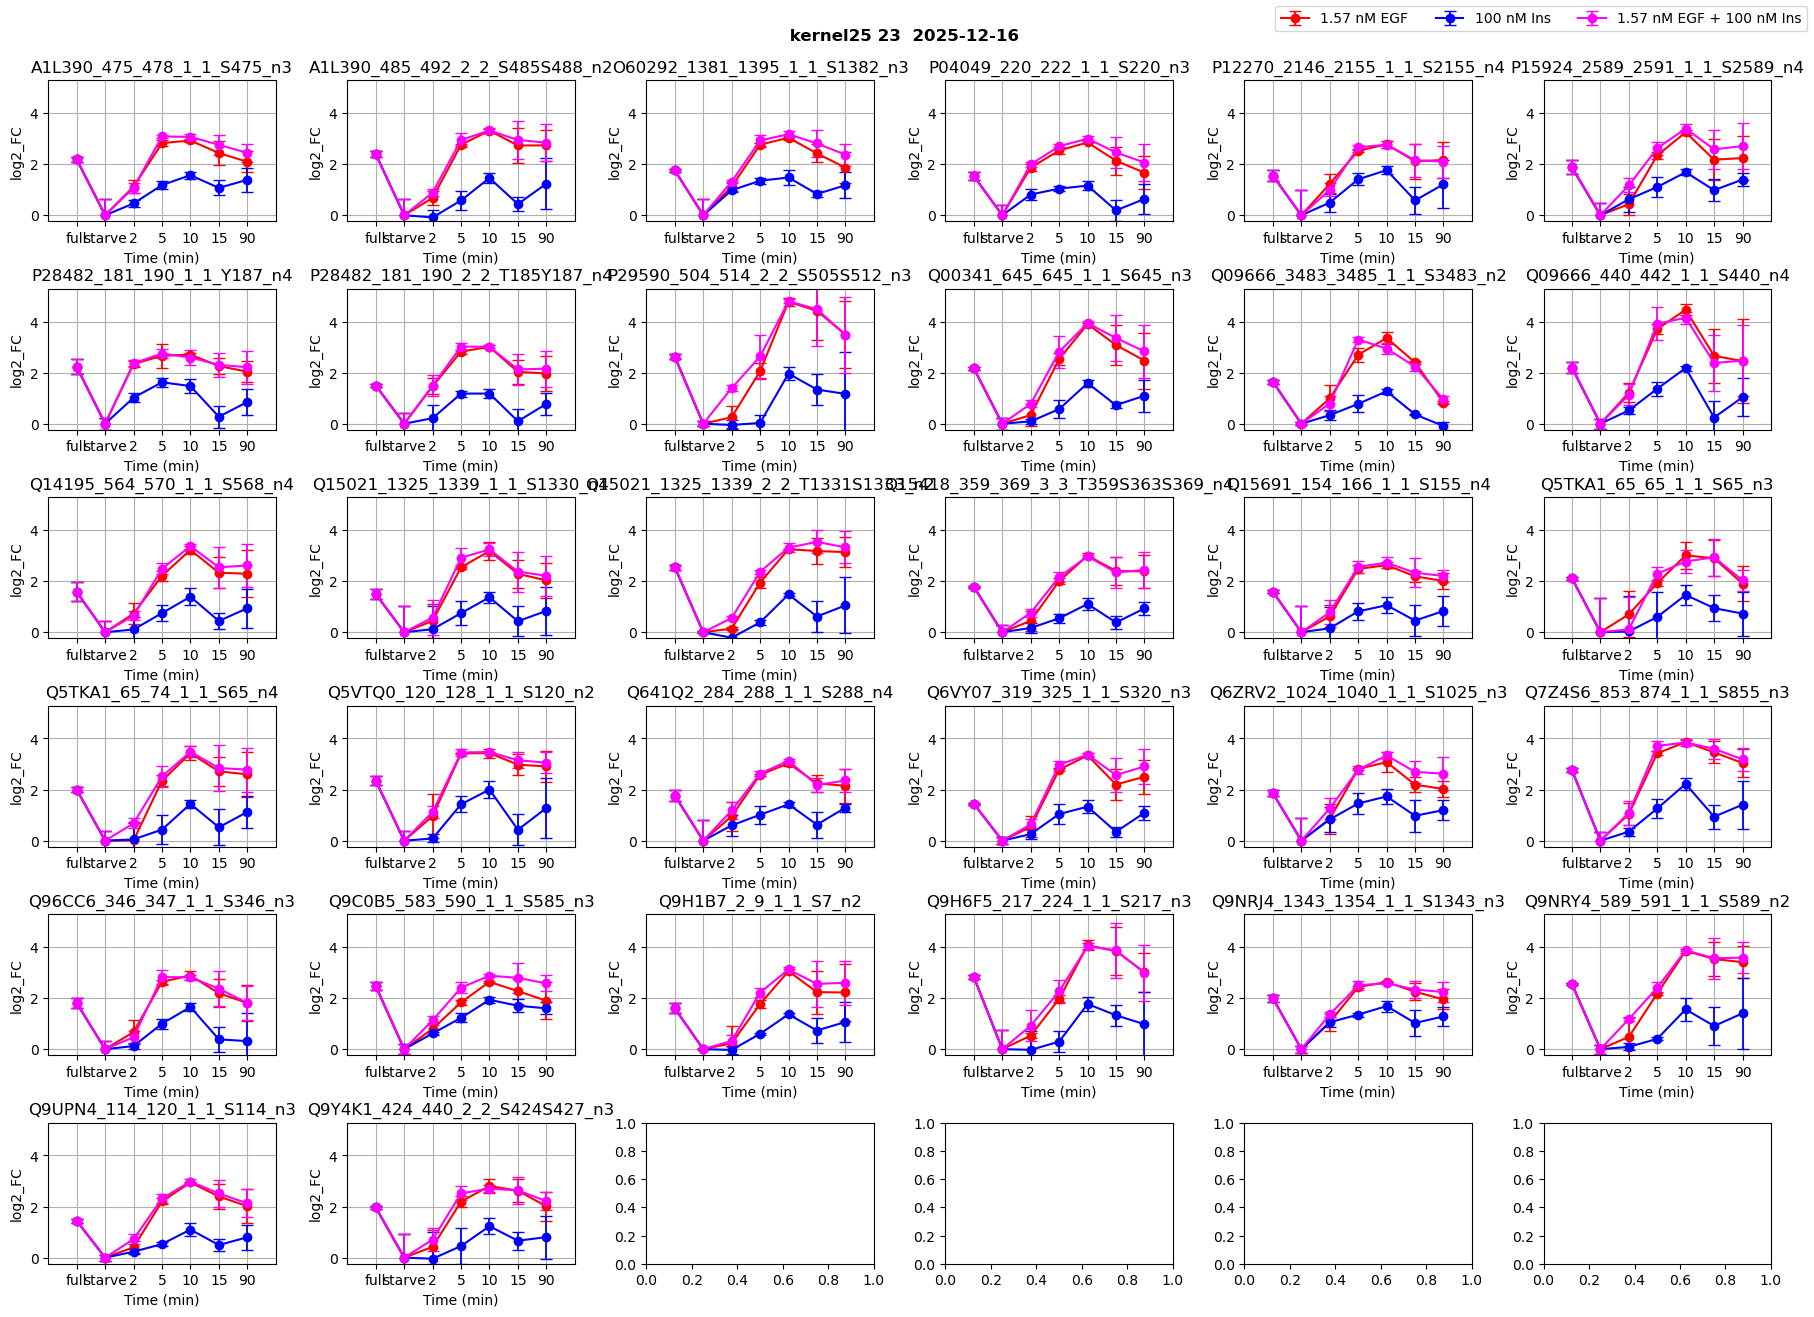

In [29]:
plot_dataset_phosphosites(df = subdata_fc,
                          cluster_column = cluster_column,
                          cluster_number = 23,
                          data_type = "log2_FC",
                          legend=['1.57 nM EGF', '100 nM Ins', '1.57 nM EGF + 100 nM Ins'],
                          color_palette = ['r', 'b', 'fuchsia'],
                          saving_path="",
                          dataset_name="",
                          saving_info="",
                          plot_individually=False,
                          fit_y_lims=False,
                          save_pdf=False,
                          save_png=False,
                          plot_close=False
                          )

In [30]:
seed = 0

clusters_predicted_transposed = gak_km.fit_predict(X_transposed)


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 1799 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 2449 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 3199 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 4049 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 4999 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 6049 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 7199 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 8449 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 9799 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 11249 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 12799 tasks      | elapsed:    0.4s
[Parallel(

Init 1
Resumed because of empty cluster
Init 1
Resumed because of empty cluster
Init 1
6569.550 --> 2769.558 --> 2451.110 --> 2381.016 --> 2350.527 --> 2336.174 --> 2326.444 --> 2320.410 --> 2312.811 --> 2308.333 --> 2305.279 --> 2305.811 --> 2304.012 --> 2303.690 --> 2300.802 --> 2300.304 --> 2295.457 --> 2293.771 --> 2294.052 --> 2294.713 --> 2294.622 --> 2295.534 --> 2295.545 --> 2297.303 --> 2298.879 --> 2302.319 --> 2304.866 --> 2308.422 --> 2312.548 --> 2313.105 --> 2316.824 --> 2320.098 --> 2324.830 --> 2327.402 --> 2327.478 --> 2327.855 --> 2328.485 --> 2331.307 --> 2332.871 --> 2333.323 --> 2333.593 --> 2334.657 --> 2334.888 --> 2334.395 --> 2333.915 --> 2333.553 --> 2333.740 --> 2333.925 --> 2333.925 --> 
Init 2
Resumed because of empty cluster
Init 2
Resumed because of empty cluster
Init 2
Resumed because of empty cluster
Init 2
Resumed because of empty cluster
Init 2
Resumed because of empty cluster
Init 2
Resumed because of empty cluster
Init 2
Resumed because of empty clu

5614


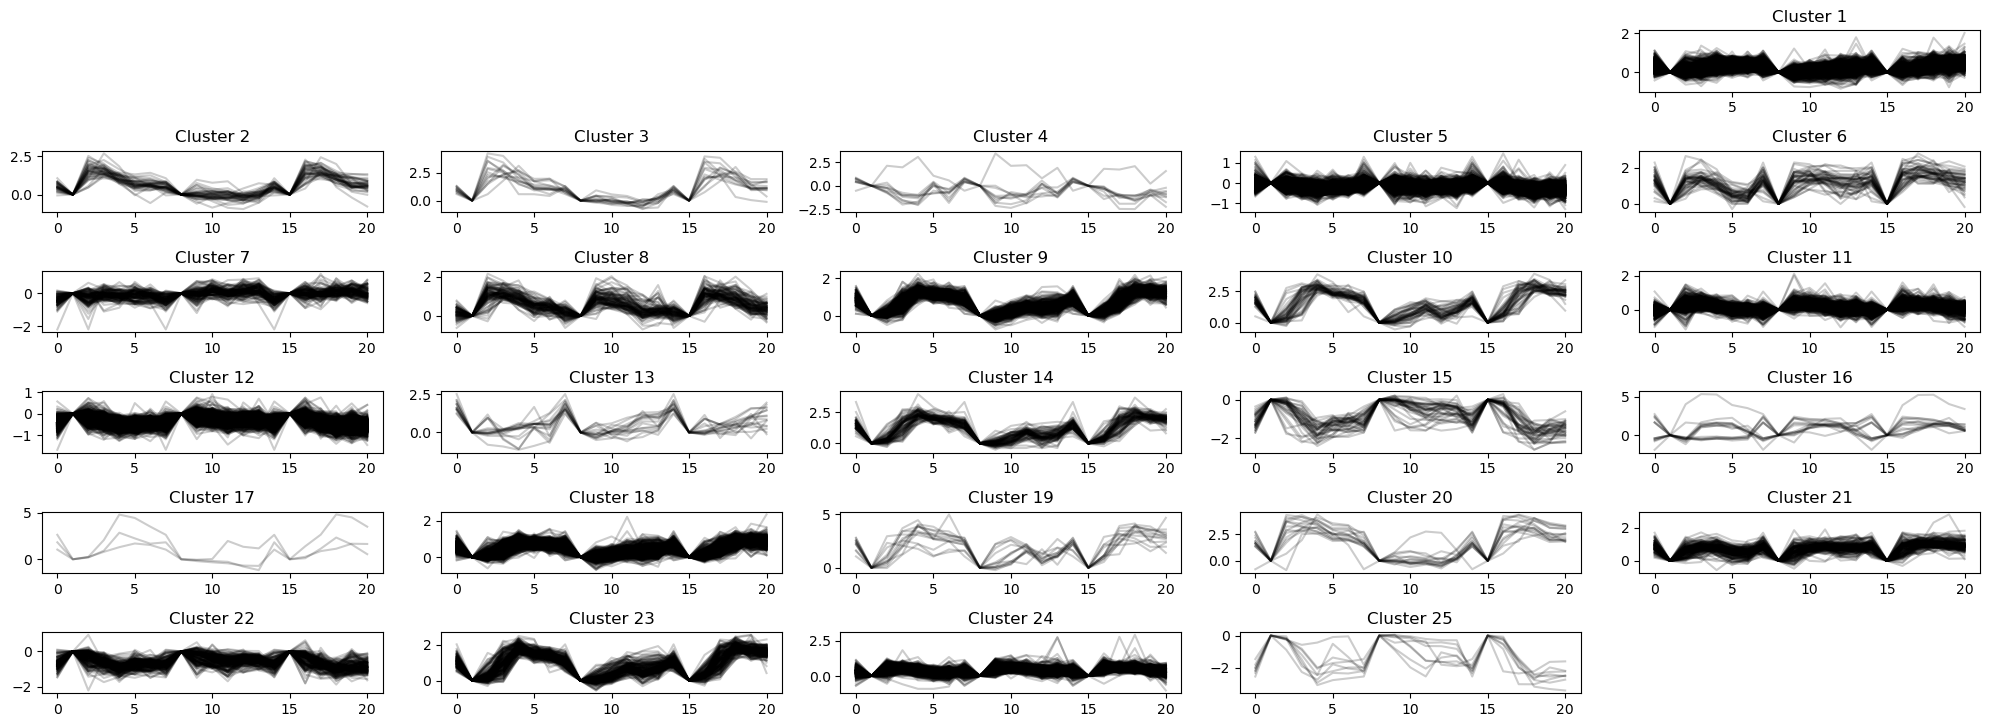

In [45]:
print(len(clusters_predicted))

plt.figure(figsize=(20,30))
for yi in range(25):
    plt.subplot(25, 5, 5 + yi)
    for xx in X[clusters_predicted == yi]:
        plt.plot(xx.ravel(), "k-", alpha=.2)
    # plt.xlim(0, sz)
    # plt.ylim(-4, 4)
    plt.title("Cluster %d" % (yi + 1))

plt.tight_layout()
plt.show()

 Plot not saved


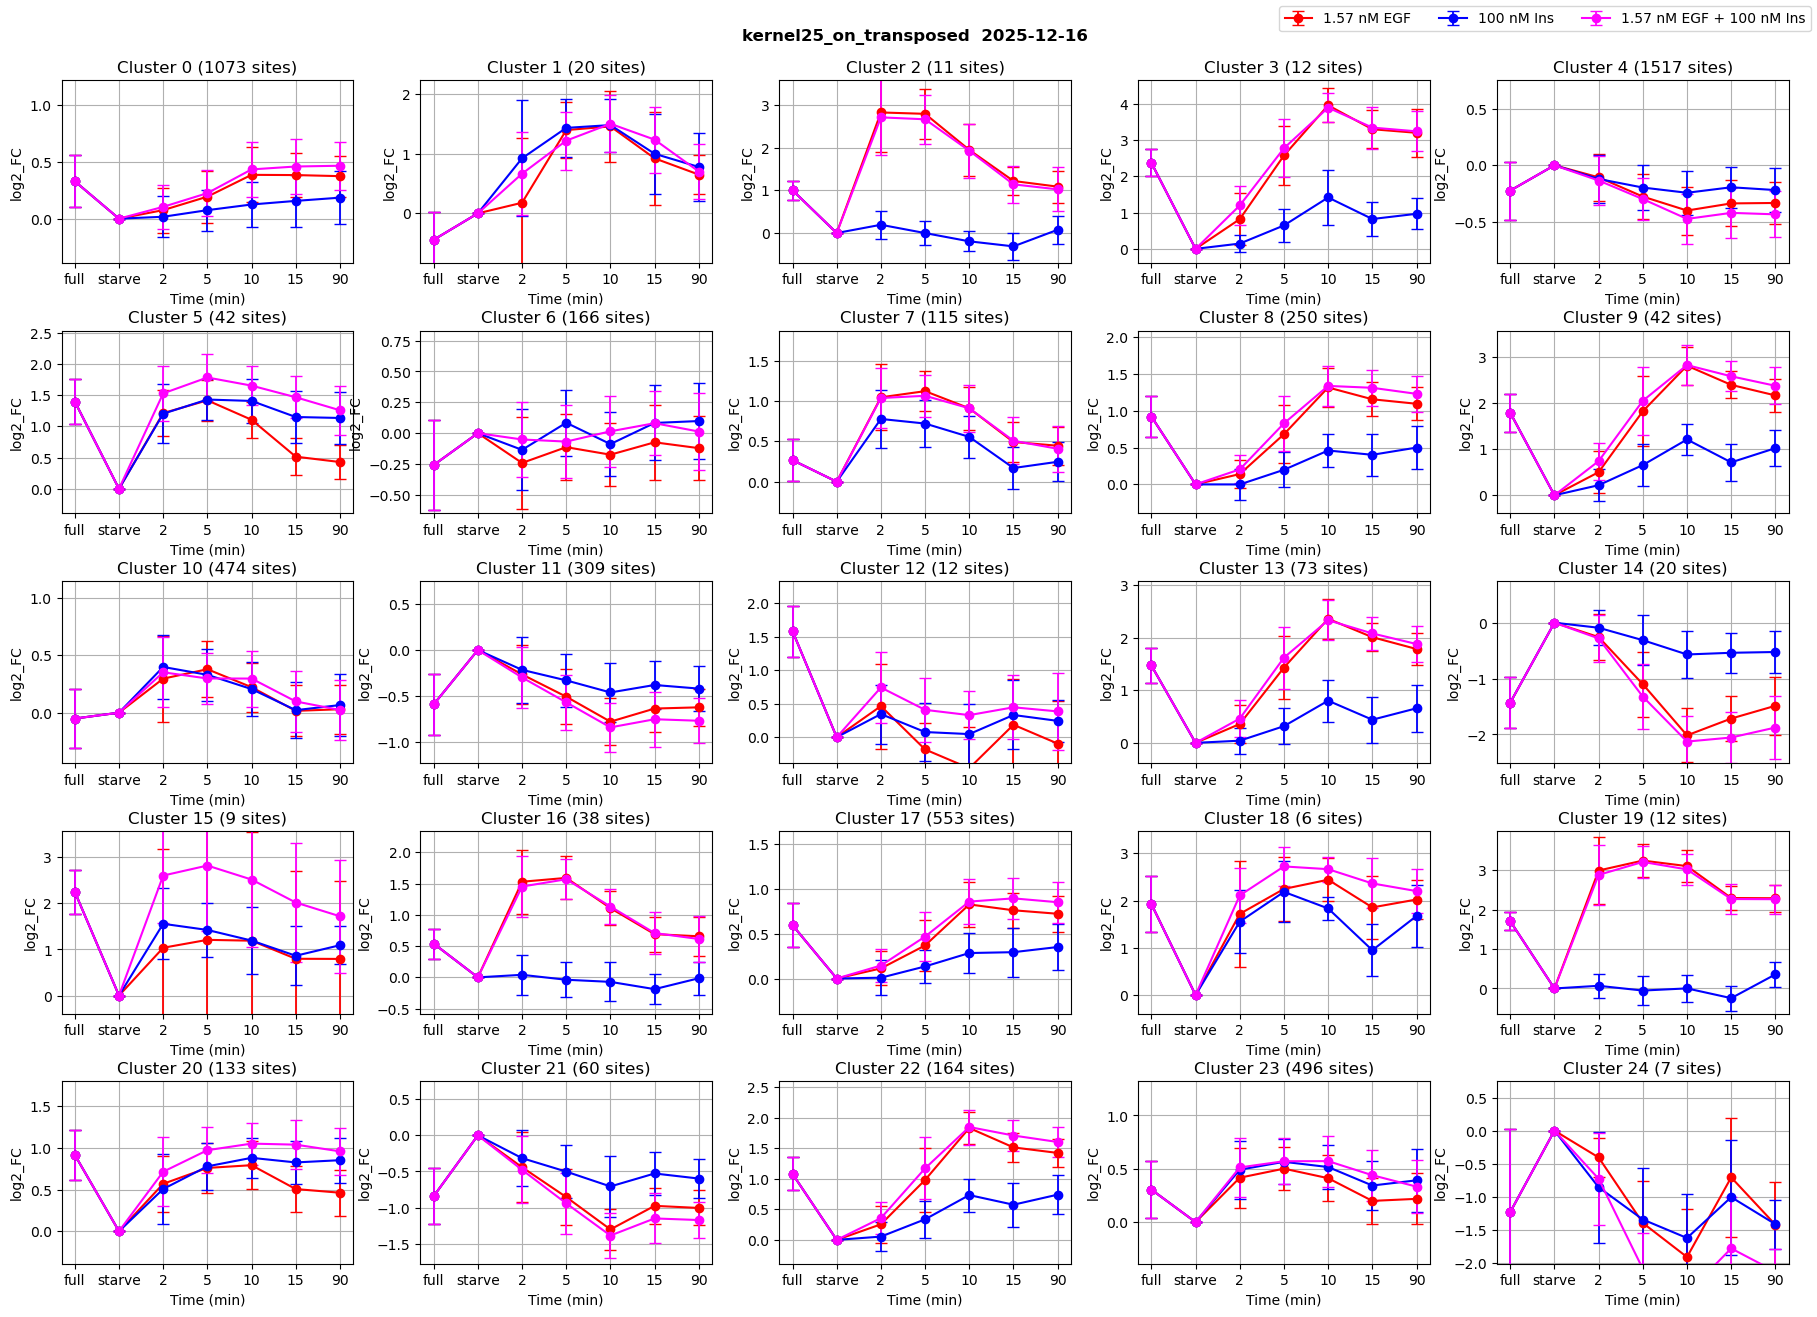

In [31]:
cluster_column_name = "kernel25_on_transposed"
subdata_fc[f"{cluster_column_name}"] = clusters_predicted_transposed
subdata_fc

cluster_column = cluster_column_name
clusters_plot(df=subdata_fc,
              legend=['1.57 nM EGF', '100 nM Ins', '1.57 nM EGF + 100 nM Ins'],
              saving_path="",
              cluster_column = cluster_column,
              data_type = "log2_FC",
              plot_different_data = True,
              cluster_name="",
              saving_info="",
              y_lims_list=False,
              save_pdf=False,
              save_png=False,
              plot_close=False)

kernel25_on_transposed_group15_ Plot not saved


/Users/ignacionavascamacho/PycharmProjects/TMT_Data_analysis/utils.py:111: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by=['site'], inplace=True)


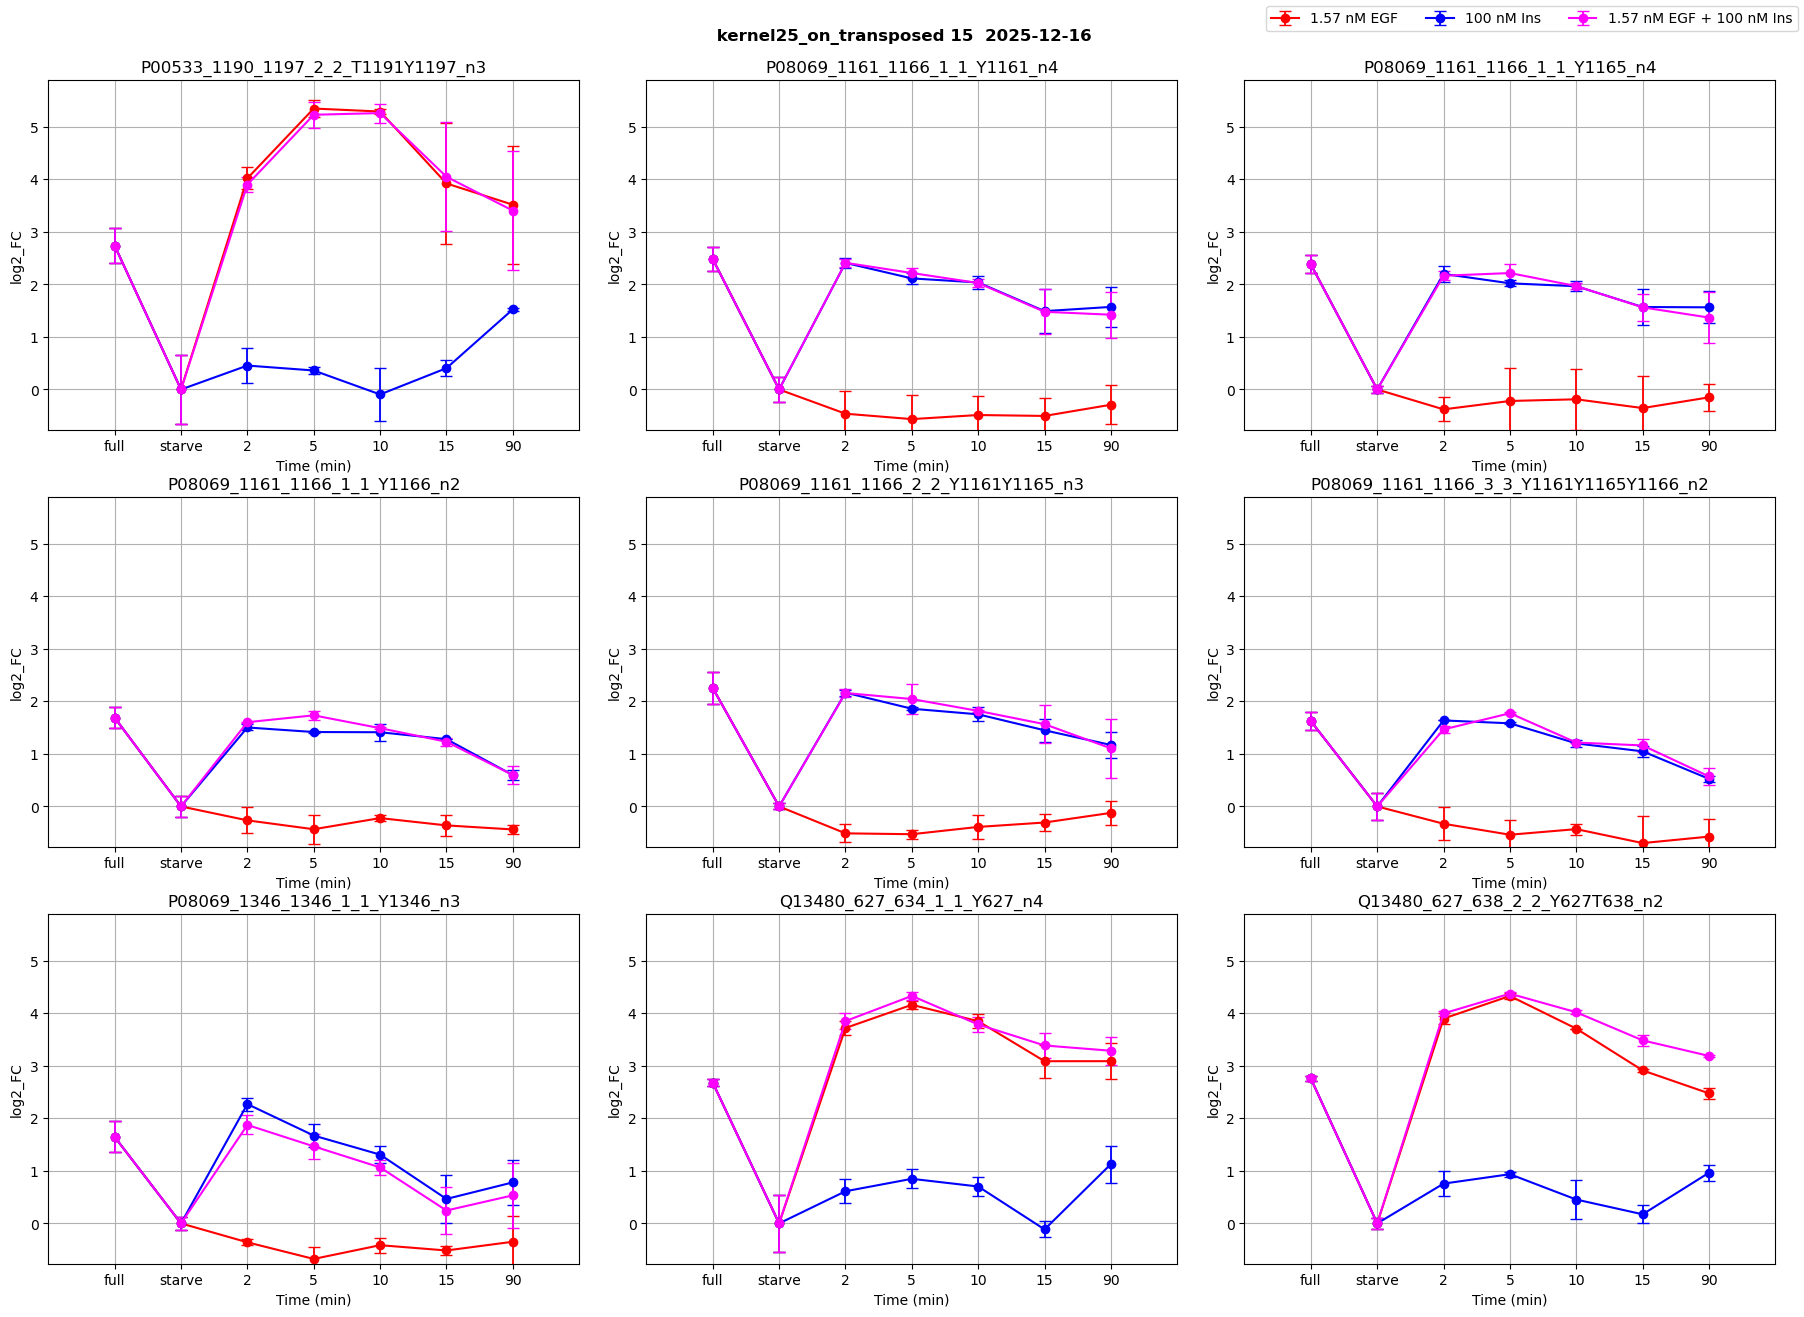

In [50]:
cluster_number = 15

plot_dataset_phosphosites(df = subdata_fc,
                          cluster_column = cluster_column,
                          cluster_number = cluster_number,
                          data_type = "log2_FC",
                          legend=['1.57 nM EGF', '100 nM Ins', '1.57 nM EGF + 100 nM Ins'],
                          color_palette = ['r', 'b', 'fuchsia'],
                          saving_path="",
                          dataset_name="",
                          saving_info="",
                          plot_individually=False,
                          fit_y_lims=False,
                          save_pdf=False,
                          save_png=False,
                          plot_close=False
                          )
uniprot_links_for(subdata_fc, protein_list=list(subdata_fc.loc[subdata_fc[cluster_column] == cluster_number]["protein_name"].unique()))

In [121]:
subdata_fc.loc[subdata_fc[cluster_column] == 24, ["protein_name","protein_Id", "site", "description", "ERK_motif", "functional_score", "kernel25", "kernel25_on_transposed"]]


,protein_name,protein_Id,site,description,ERK_motif,functional_score,kernel25,kernel25_on_transposed
59,SHTN1,A0MZ66,A0MZ66_381_386_1_1_S384~SHPsGSGAK,Shootin-1 OS=Homo sapiens OX=9606 GN=SHTN1 PE=...,0.0,0.000000,10,24
2678,TBC1D4,O60343,O60343_588_591_1_1_S591~LGSVDsFER,TBC1 domain family member 4 OS=Homo sapiens OX...,0.0,0.266507,10,24
6955,EEF2,P13639,P13639_57_59_2_2_T57T59~FtDtRKDEQER,Elongation factor 2 OS=Homo sapiens OX=9606 GN...,0.0,0.847157,10,24
9945,IRS1,P35568,P35568_329_351_1_1_S348~ASSDGEGTMSRPASVDGSPVsP...,Insulin receptor substrate 1 OS=Homo sapiens O...,1.0,0.593948,10,24
35520,CIC,Q96RK0,Q96RK0_1340_1345_1_1_S1345~AASEDMTsDEER,Protein capicua homolog OS=Homo sapiens OX=960...,0.0,0.000000,10,24
35553,CIC,Q96RK0,Q96RK0_2306_2318_1_1_S2318~KNSTDLDSAPEDPTsPK;N...,Protein capicua homolog OS=Homo sapiens OX=960...,0.0,0.000000,10,24
36878,NAA38,Q9BRA0,Q9BRA0_22_36_1_1_S29~QSSSSAGDsDGEREDSAAER,"N-alpha-acetyltransferase 38, NatC auxiliary s...",0.0,0.462117,10,24
44765,ZBTB21,Q9ULJ3,Q9ULJ3_409_425_1_1_S422~SFSASQSTDREGAsPVTEVR,Zinc finger and BTB domain-containing protein ...,1.0,0.427362,10,24


In [114]:
subdata_fc.loc[subdata_fc["protein_name"] == "GAB1", ["protein_name", "site", "description", "ERK_motif", "functional_score",f"{cluster_column}"]]


,protein_name,site,description,ERK_motif,functional_score,kernel25_on_transposed
17663,GAB1,Q13480_251_259_1_1_Y259~APSASVDSSLyNLPR,GRB2-associated-binding protein 1 OS=Homo sapi...,0.0,0.944588,20
17669,GAB1,Q13480_417_419_1_1_S419~SSsLEGFHNHFK,GRB2-associated-binding protein 1 OS=Homo sapi...,0.0,0.571208,8
17673,GAB1,Q13480_627_634_1_1_Y627~GDKQVEyLDLDLDSGK,GRB2-associated-binding protein 1 OS=Homo sapi...,0.0,0.942000,19
17676,GAB1,Q13480_627_638_2_2_Y627T638~GDKQVEyLDLDLDSGKStPPR,GRB2-associated-binding protein 1 OS=Homo sapi...,1.0,0.942000,19
17683,GAB1,Q13480_645_659_1_1_Y659~SSGSGSSVADERVDyVVVDQQK,GRB2-associated-binding protein 1 OS=Homo sapi...,0.0,0.909687,9
17685,GAB1,Q13480_659_659_1_1_Y659~VDyVVVDQQK,GRB2-associated-binding protein 1 OS=Homo sapi...,0.0,0.909687,9


---------------------------

Ploting sites of protein STAM
STAM_Q92783_156_156_1_1_S156~AsPALVAK_ Plot not saved


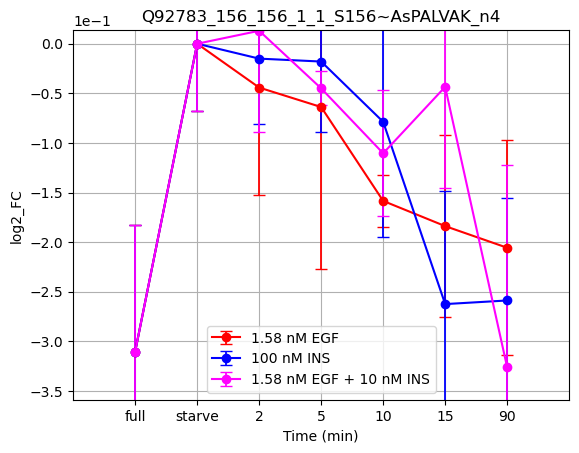

In [137]:
proteins = ["STAM"]#["BRAF", "GAB1", "AHNAK2", "RPS6K3", "SOS1"]
plot_protein_phosphosites(df_2_hME1_scaled, data_type = "log2_FC",
                          proteins = proteins, replicates = False,  exclude_rep = [], #exclude_rep in format: 'rep1', 'rep2', 'rep3', 'rep4'
                          legend_plot = ['1.58 nM EGF', '100 nM INS', '1.58 nM EGF + 10 nM INS'], color_palette = ['r', 'b', 'fuchsia'], #['r', 'b', 'fuchsia']
                          saving_path = "",
                          saving_info = "", title_info = "",
                          plot_individually = True, fit_y_lims = False,
                          plot_close = False,
                          save_pdf = False, save_png = False,)

------------------------------------
# Clustering evaluation methods
----------------------------

from tslearn there are functions that should be more usefull than all these weird Chatgpt codes with i dont fully understand

Short answer: **(sites, time, conditions) → (239, 7, 3)**.

From tslearn.metrics:
- cdsit_dtw(dataset1[, dataset2, ...]): Compute cross-similarity matrix using Dynamic Time Warping (DTW) similarity measure.
- ctw(s1, s2[, max_iter, n_components, ...]): Compute Canonical Time Warping (CTW) similarity measure between (possibly multidimensional) time series and return the similarity.
- dtw(s1, s2[, global_constraint, ...]): Compute Dynamic Time Warping (DTW) similarity measure between (possibly multidimensional) time series and return it.
- frechet(s1, s2[, global_constraint, ...]): Compute Frechet similarity [Ra7bc9d1b5c92-1] measure between (possibly multidimensional) time series and return it.

other useful code could be:
- gak(s1, s2[, sigma, be]): Compute Global Alignment Kernel (GAK) between (possibly multidimensional) time series and return it.

Chec the modules:
- tslearn.preprocessing
- tslearn.svm

In [47]:
df_cluster

,protein_Id,description,protein_name,Peptide,MaxPepProbability,site_start,site_end,n_sites,localized_sites,phospho_sites,...,KMeans_81clusters_DTW_on_log2_FC_[locSite>0]_[nrep>1]_[FC>1],KMeans_81clusters_DTW_on_log2_FC_[locSite>0]_[nrep>1]_[03>FC>05],KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>05]_[ERKmotif0],KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>05]_[Fscore>05],KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>05]_[ERKmotif0]_[Fscore>05],KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>05]_[ERKmotif1],KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>05]_[ERKmotif1]_[Fscore>05],KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>05],KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>1],KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[03<FC<05]
0,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SGSGNFGGGR,0.9956,197,199,1,0,0,...,999,999,999,999,999,999,999,999,999,999
1,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SGsGNFGGGR,1.0000,197,199,1,1,S199,...,43,999,21,999,999,999,999,10,35,999
2,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SKSEsPKEPEQLR,1.0000,2,6,1,1,S6,...,999,999,999,999,999,999,999,999,999,999
3,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,sKsESPK,0.9894,2,6,2,2,S2;S4,...,999,999,999,999,999,999,999,999,999,999
4,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,NQGGYGGSSSSSSYGSGR;NQGGYGGSSSSSSYGSGRRF,1.0000,305,316,1,0,0,...,999,999,999,999,999,999,999,999,999,999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50009,rev_Q5VWT5,0,0,GALMNRRGtHVNtMQIK,0.9898,303,307,2,2,T303;T307,...,999,999,999,999,999,999,999,999,999,999
50010,rev_Q8N6M0,0,0,LQDEIAKYMCHGDsPIQK,0.9970,135,141,1,1,S141,...,999,999,999,999,999,999,999,999,999,999
50011,rev_Q96M83,0,0,ERGPtIKK,0.9835,505,505,1,1,T505,...,999,999,999,999,999,999,999,999,999,999
50012,rev_Q9ULL1,0,0,SSASSSTSGFSVPR,0.9787,1366,1376,2,0,0,...,999,999,999,999,999,999,999,999,999,999


In [61]:
import tslearn as tsl

cluster_column = "KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>05]_[ERKmotif0]_[Fscore>05]" #"kernel25_on_transposed"
cluster_number = 999 # 2
df1 = df_cluster.loc[df_cluster[cluster_column] == cluster_number]
# df2 = subdata_fc.loc[subdata_fc[cluster_column] == 3]

X1_tp, y_qc = reshape_df(df = df1, time_series = column_selection,  labels="site",  dimensions = 3, len_time_serie = 7, transpose = True)
# X2_tp, y_qc = reshape_df(df = df2, time_series = column_selection,  labels="site",  dimensions = 3, len_time_serie = 7, transpose = True)

# TRANSPOSED MATRIX
print(len(X1_tp), X1_tp.shape) #, len(X2_tp))
dist_tp = tsl.metrics.cdist_dtw(dataset1 = X1_tp)
# dist_tp

49168 (49168, 7, 3)


KeyboardInterrupt: 

In [72]:
data_type = "FC_scaled"

column_selection = [element for element in df_cluster.columns.tolist() if f"{data_type}" in element and "cluster" not in element]
column_selection

['FC_scaled_EGF_full',
 'FC_scaled_EGF_starve',
 'FC_scaled_EGF_2',
 'FC_scaled_EGF_5',
 'FC_scaled_EGF_10',
 'FC_scaled_EGF_15',
 'FC_scaled_EGF_90',
 'FC_scaled_INS_full',
 'FC_scaled_INS_starve',
 'FC_scaled_INS_2',
 'FC_scaled_INS_5',
 'FC_scaled_INS_10',
 'FC_scaled_INS_15',
 'FC_scaled_INS_90',
 'FC_scaled_EGFnINS_full',
 'FC_scaled_EGFnINS_starve',
 'FC_scaled_EGFnINS_2',
 'FC_scaled_EGFnINS_5',
 'FC_scaled_EGFnINS_10',
 'FC_scaled_EGFnINS_15',
 'FC_scaled_EGFnINS_90']

In [73]:
cluster_metric = {}
# cluster_column = "kernel25"
for cluster in sorted(df_cluster[cluster_column].unique()):
    if cluster == 999:
        continue
    # print(cluster)
    df1 = df_cluster.loc[df_cluster[cluster_column] == cluster]
    X1_tp, y_qc = reshape_df(df = df1, time_series = column_selection,  labels="site",  dimensions = 3, len_time_serie = 7, transpose = True)

    dist_tp = tsl.metrics.cdist_dtw(dataset1 = X1_tp)

    mean_dtw_tp = np.mean(dist_tp[np.triu_indices_from(dist_tp, k=1)])

    cluster_metric[cluster] = mean_dtw_tp

cluster_metric

/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice

{0: 0.9749596790855144,
 1: 1.197099392425772,
 2: 1.6481253232936517,
 3: 0.6036286234133447,
 4: 0.9607181140929825,
 5: 0.6997696466532857,
 6: 1.1051658179692212,
 7: 1.1441346379574768,
 8: 1.073652640925904,
 9: 0.7860859520357631,
 10: 1.9001822994256843,
 11: 0.6987088774173711,
 12: 0.9290407579520463,
 13: 1.4989318013078898,
 14: 0.9443808140505496,
 15: 0.7790300657916651,
 16: 0.8128561199601629,
 17: 1.0518753824496314,
 18: 0.8719132064263831,
 19: nan,
 20: 0.8355812483803844,
 21: 1.585193324403526,
 22: 1.4218558113082744,
 23: 1.0943015166709802,
 24: 0.854694052786689,
 25: 0.9129763831747002,
 26: 0.8018927644070929,
 27: 1.1568282015971023,
 28: 1.4159576387780715,
 29: 0.902643611779798,
 30: 1.1750812499035859,
 31: 1.006144484832842,
 32: 0.906791510037179,
 33: 0.8390992353238247,
 34: 0.8724910465973111,
 35: 1.2115240676687653,
 36: 1.0211320940980868,
 37: nan,
 38: 0.8996214656793737,
 39: 0.7297797643572421,
 40: 1.514977045242756,
 41: 1.4852503394550787

<BarContainer object of 81 artists>

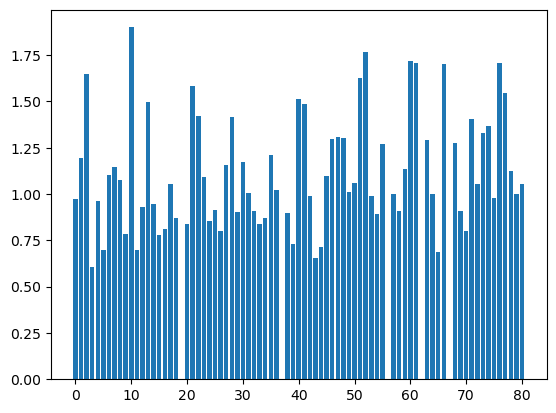

In [74]:
plt.bar(x = cluster_metric.keys(), height = cluster_metric.values())

In [203]:
# NOT TRANSPOSED MATRIX
# X1, y_qc = reshape_df(df = df1, time_series = column_selection,  labels="site",  dimensions = 3, len_time_serie = 7, transpose = False)
#
# dist = tsl.metrics.cdist_dtw(dataset1 = X1)
# dist

In [42]:
# TRANSPOSED SCALED DATAFRAME
data_type = "FC_scaled"

column_names = subdata_fc.columns.tolist()
column_selection_scaled = [element for element in column_names if f"{data_type}" in element]


X1_scaled_tp, y_qc = reshape_df(df = df1, time_series = column_selection_scaled,  labels="site",  dimensions = 3, len_time_serie = 7, transpose = True)

dist_scaled_tp = tsl.metrics.cdist_dtw(dataset1 = X1_scaled_tp)
# dist_scaled_tp

In [58]:
cluster_metric_scaled = {}
for cluster in sorted(subdata_fc[cluster_column].unique()):
    df1 = subdata_fc.loc[subdata_fc[cluster_column] == cluster]
    X1_tp, y_qc = reshape_df(df = df1, time_series = column_selection_scaled,  labels="site",  dimensions = 3, len_time_serie = 7, transpose = True)

    dist_tp = tsl.metrics.cdist_dtw(dataset1 = X1_tp)

    mean_dtw_tp = np.mean(dist_tp[np.triu_indices_from(dist_tp, k=1)])

    cluster_metric_scaled[cluster] = mean_dtw_tp

cluster_metric_scaled

{0: 0.6506310035593315,
 1: 3.1348967812253794,
 2: 1.4577525512520797,
 3: 1.1767145580275635,
 4: 1.3107324186663443,
 5: 1.283085614147401,
 6: 1.5049570663732181,
 7: 1.9313032738466047,
 8: 1.1464587228788827,
 9: 1.07826210967503,
 10: 0.9443122967679453,
 11: 0.8200627346228204,
 12: 1.7186926020752833,
 13: 1.1113310680276758,
 14: 0.8236914404032059,
 15: 0.8422199000820184,
 16: 1.2279784390954835,
 17: 1.9033533603410902,
 18: 0.9870246803443455,
 19: 1.1427793196025429,
 20: 0.7109795512182328,
 21: 1.378361854803794,
 22: 0.6959082025617053,
 23: 0.583608110099081,
 24: 1.517679859907042}

<BarContainer object of 25 artists>

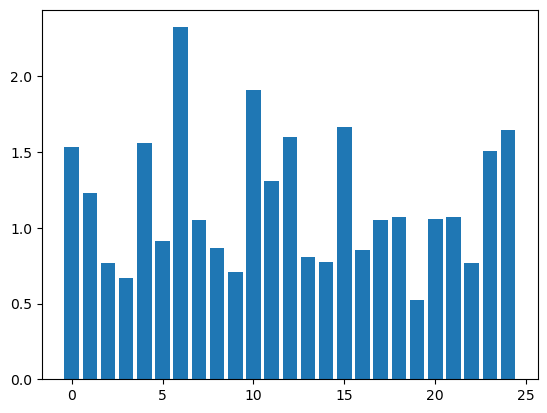

In [49]:
plt.bar(x = cluster_metric_scaled.keys(), height = cluster_metric_scaled.values())

In [202]:
# NOT TRANSPOSED SCALED DATAFRAME
# X1_scaled, y_qc = reshape_df(df = df1, time_series = column_selection_scaled,  labels="site",  dimensions = 3, len_time_serie = 7, transpose = False)
#
# dist_scaled =tsl.metrics.cdist_dtw(dataset1 = X1_scaled)
# dist_scaled

In [34]:
mean_dtw_tp = np.mean(dist_tp[np.triu_indices_from(dist_tp, k=1)])
# mean_dtw = np.mean(dist[np.triu_indices_from(dist, k=1)])
mean_dtw_scaled_tp = np.mean(dist_scaled_tp[np.triu_indices_from(dist_scaled_tp, k=1)])
# mean_dtw_scaled = np.mean(dist_scaled[np.triu_indices_from(dist_scaled, k=1)])
print(f"The mean distances within the cluster {cluster_number} are: {mean_dtw_tp},  {mean_dtw_scaled_tp}")


The mean distances within the cluster 2 are: 2.5182413354738005,  0.7700423120057898


In [35]:
median_dtw_tp = np.median(dist_tp[np.triu_indices_from(dist_tp, k=1)])
# median_dtw = np.median(dist[np.triu_indices_from(dist, k=1)])
median_dtw_scaled_tp = np.median(dist_scaled_tp[np.triu_indices_from(dist_scaled_tp, k=1)])
# median_dtw_scaled = np.median(dist_scaled[np.triu_indices_from(dist_scaled, k=1)])
print(f"The mean distances within the cluster {cluster_number} are: {median_dtw_tp}, {median_dtw_scaled_tp}")


The mean distances within the cluster 2 are: 2.4354818923775503, 0.7207185425103958


In [164]:
def reshape_df(df,
               time_series,
               dimensions,
               len_time_serie,
               labels = str,
               transpose = False):
    '''Reshape dataframe so it is multivariate format. Return the dataframe in numpy format so can be used, and list with the names of myseries'''

    sub_df = df[time_series].copy()
    mySeries = sub_df.to_numpy()
    namesofMySeries = df[labels]

    multivariate_shape = (len(df), dimensions, len_time_serie)
    multivariate_df = np.reshape(mySeries, multivariate_shape)
    if transpose == True:
        multivariate_df = multivariate_df.transpose(0, 2, 1)

    return multivariate_df, namesofMySeries

data_type = "log2_FC"

column_names = subdata_fc.columns.tolist()
column_selection = [element for element in column_names if f"{data_type}" in element]

X_qc, y_qc = reshape_df(df = subdata_fc, time_series = column_selection, labels="site",  dimensions = 3, len_time_serie = 7)
print(f"The size of the dataset is {X.shape}, labels: {y.shape}")

X_qc_transposed, y_qc = reshape_df(df = subdata_fc, time_series = column_selection,  labels="site",  dimensions = 3, len_time_serie = 7, transpose = True)
print(f"The transposed matrix has shape {X_transposed.shape}, labels: {y.shape}")

The size of the dataset is (5614, 3, 7), labels: (5614,)
The transposed matrix has shape (5614, 7, 3), labels: (5614,)


In [86]:
a = cluster_similarity_cdist_dtw(
        df_cluster,
        transpose = False,
        data_type = "log2_FC",
        cluster_column_name = "KMeans_81clusters_DTW_on_FC_scaled_[locSite>0]_[nrep>1]_[FC>05]_[ERKmotif0]_[Fscore>05]" ,
        mean = True,
        median = False
)
a

/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice

{0: 1.3143732104667045,
 1: 0.9790027102901147,
 2: 2.0968457255867725,
 3: 2.361548507123691,
 4: 1.6221961903891902,
 5: 1.7226508762869182,
 6: 1.0949443474432432,
 7: 1.101299911031969,
 8: 0.9471260159892096,
 9: 2.3496663750940217,
 10: 1.4926478574818105,
 11: 2.159709629939663,
 12: 2.150422217762081,
 13: 1.0841130795528149,
 14: 1.0760331969698536,
 15: 0.8902999228065079,
 16: 2.6687845336003915,
 17: 3.008326494779462,
 18: 1.2931339915823614,
 19: nan,
 20: 1.389373262551641,
 21: 1.3204117009233765,
 22: 1.1902544682564602,
 23: 1.4258406906652024,
 24: 1.9636748338820567,
 25: 0.6707807919611104,
 26: 2.4090838801523073,
 27: 1.725439144568648,
 28: 0.9778287906849512,
 29: 1.6582376958202658,
 30: 1.9443551530064482,
 31: 1.720052630201776,
 32: 0.8607468568415094,
 33: 1.9398801404644626,
 34: 2.8365078944782534,
 35: 1.3465338371646052,
 36: 2.244778139952947,
 37: nan,
 38: 2.499515927403533,
 39: 4.77474889323503,
 40: 1.105099548115863,
 41: 1.2644921434268184,
 42

<BarContainer object of 81 artists>

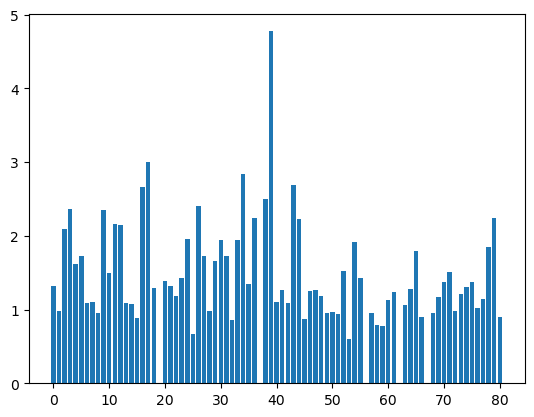

In [87]:
plt.bar(x = a.keys(), height = a.values())